# 🛒 E-Commerce Customer Intelligence & Campaign Decision Engine

### Project goal
Turn raw e-commerce data into **decisions**: who are our customers, which carts are worth recovering, what should we say to whom, and how much discount is safe.

**Pipeline:** Data cleaning & EDA → SQL → Customer 360 → RFM → K-Means segments → purchase-prediction audit → recommender → review sentiment → **policy engine + LLM writer + guardrails** → Streamlit/Flask → BI exports → deployment

### Two datasets (they are **not** linked — the sales file has no customer ID)
| File | What it is | Used in |
|---|---|---|
| `sales_dataset.xlsx` | 128,949 Amazon-India order lines (Mar–Jun 2022) | Phases 1, 2, 11 |
| `Ecommerce.csv` | 25,000 customer sessions, 8,442 customers | Phases 3–10 |

### What this project **is** and **is not**
- ✅ A complete, tested analytics + decision pipeline with honest evaluation.
- ✅ Rule-based decisions with an LLM only for wording, and guardrails around it.
- ❌ Not a highly accurate purchase predictor — the data does not contain that signal (proved in Phase 6B).
- ❌ Not an autonomous agent system — it is a policy engine + LLM writer.

### Working setup
- **Google Colab:** Python, cleaning, EDA, ML · **MySQL Workbench:** SQL (also re-run in-notebook with sqlite) · **App:** Streamlit + Flask · **BI:** Power BI / Tableau

## 📍 PROJECT ROADMAP & STATUS

| Phase | Status | Output |
|---|---|---|
| 1. Sales cleaning & EDA (+1B gross vs net) | ✅ | Clean data, business insights, net revenue |
| 2. SQL | ✅ | Queries run in MySQL **and** verified in-notebook (sqlite) |
| 3. Customer 360 | ✅ | One row per customer |
| 4. RFM | ✅ | Purchase-based Recency / Frequency / Monetary |
| 5. K-Means | ✅ | 4 named segments |
| 6 / 6B. Purchase prediction | ✅ | Leakage audit + honest cart-stage model |
| 7 / 7B. Recommender | ✅ | Item-item CF + baselines |
| 8. Reviews & sentiment | ✅ | Rating-based sentiment + significance tests |
| 9. Decision engine | ✅ | Policy + LLM writer + guardrails + tests |
| 10. Streamlit + Flask | ✅ | `app.py`, `api.py` |
| 11. BI exports | ✅ (dashboards: you build in Power BI / Tableau) | `bi_exports/*.csv` |
| 12. Deployment | ⏳ | GitHub + Streamlit Cloud (checklist at the end) |

> Every phase ends with a **🎤 Interview Card**: Kyun / Kya / Kaise / Result / Limit + likely questions.

# PHASE 1 — E-COMMERCE SALES DATA ANALYSIS

**Purpose:** First understand the business data before doing ML.

## 1. Import Libraries

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Sales Dataset

In [87]:
from google.colab import files

uploaded = files.upload()

Saving sales_dataset.xlsx to sales_dataset (1).xlsx


In [88]:
# Read the Excel file

df = pd.read_excel("sales_dataset.xlsx")
print("Dataset loaded successfully ✅")

Dataset loaded successfully ✅


## 3. Understand the Dataset

In [89]:
# First 5 rows

df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,171-7326790-9044369,2022-03-31,Shipped,Amazon,Amazon.in,Expedited,JNE3614,JNE3614-KR-L,kurta,L,...,INR,453.00,ARANI TIRUVANNAMALAI DISTRICT,TAMIL NADU,632317.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
1,171-7326790-9044369,2022-03-31,Shipped,Amazon,Amazon.in,Expedited,JNE3294,JNE3294-KR-L,kurta,L,...,INR,353.00,ARANI TIRUVANNAMALAI DISTRICT,TAMIL NADU,632317.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
2,171-7192082-3049169,2022-03-31,Cancelled,Merchant,Amazon.in,Standard,JNE3461,JNE3461-KR-L,kurta,L,...,INR,360.95,ARANI TIRUVANNAMALAI DISTRICT,TAMIL NADU,632317.0,IN,NaN,False,Easy Ship,NaN
3,402-9467302-4929937,2022-03-31,Shipped,Amazon,Amazon.in,Expedited,JNE3405,JNE3405-KR-XXXL,kurta,3XL,...,INR,449.00,PANCHKULA,HARYANA,134116.0,IN,NaN,False,NaN,NaN
4,405-1392423-9557138,2022-03-31,Shipped,Amazon,Amazon.in,Expedited,JNE3068,JNE3068-KR-A-L,kurta,L,...,INR,688.00,Tirupati,ANDHRA PRADESH,517501.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN


In [90]:
# Number of rows and columns

df.shape

(128949, 23)

In [91]:
# Column names

df.columns.tolist()

['Order ID',
 'Date',
 'Status',
 'Fulfilment',
 'Sales Channel',
 'ship-service-level',
 'Style',
 'SKU',
 'Category',
 'Size',
 'ASIN',
 'Courier Status',
 'Qty',
 'currency',
 'Amount',
 'ship-city',
 'ship-state',
 'ship-postal-code',
 'ship-country',
 'promotion-ids',
 'B2B',
 'fulfilled-by',
 'Unnamed: 22']

In [92]:
# Data types and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            128949 non-null  object        
 1   Date                128949 non-null  datetime64[ns]
 2   Status              128949 non-null  object        
 3   Fulfilment          128949 non-null  object        
 4   Sales Channel       128949 non-null  object        
 5   ship-service-level  128949 non-null  object        
 6   Style               128949 non-null  object        
 7   SKU                 128949 non-null  object        
 8   Category            128949 non-null  object        
 9   Size                128949 non-null  object        
 10  ASIN                128949 non-null  object        
 11  Courier Status      122078 non-null  object        
 12  Qty                 128949 non-null  int64         
 13  currency            121155 no

In [93]:
# Missing values in each column

df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [94]:
# Exact duplicate rows

df.duplicated().sum()

np.int64(6)

In [95]:
# Basic statistics for numeric columns

df.describe()

,Date,Qty,Amount,ship-postal-code,Unnamed: 22
count,128949,128949.000000,121155.000000,128916.000000,79908.0
mean,2022-05-12 11:46:37.636275200,0.904629,648.550806,463978.298008,0.0
min,2022-03-31 00:00:00,0.000000,0.000000,110001.000000,0.0
25%,2022-04-20 00:00:00,1.000000,449.000000,382421.000000,0.0
50%,2022-05-10 00:00:00,1.000000,605.000000,500033.000000,0.0
75%,2022-06-04 00:00:00,1.000000,788.000000,600024.000000,0.0
max,2022-06-29 00:00:00,15.000000,5584.000000,989898.000000,0.0
std,NaN,0.314782,281.218324,191473.322953,0.0


## 4. Data Quality Audit

We first inspect suspicious/missing values. We do **not** fill every missing value blindly; the treatment depends on its business meaning.

In [96]:
# Check the Excel-generated column
print(df["Unnamed: 22"].value_counts(dropna=False).head(10))

Unnamed: 22
0.0    79908
NaN    49041
Name: count, dtype: int64


In [97]:
# Currency values
print(df["currency"].value_counts(dropna=False))

currency
INR    121155
NaN      7794
Name: count, dtype: int64


In [98]:
# Country values
print(df["ship-country"].value_counts(dropna=False))

ship-country
IN     128916
NaN        33
Name: count, dtype: int64


In [99]:
# Order status
print(df["Status"].value_counts())

Status
Shipped                          77767
Shipped - Delivered to Buyer     28771
Cancelled                        18341
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64


In [100]:
# Missing Amount by order status
print(df[df["Amount"].isnull()]["Status"].value_counts())

Status
Cancelled                       7563
Shipped                          209
Shipped - Delivered to Buyer       9
Shipping                           8
Shipped - Returned to Seller       3
Pending                            2
Name: count, dtype: int64


In [101]:
# Fulfilment vs fulfilled-by relationship
pd.crosstab(df["Fulfilment"], df["fulfilled-by"], dropna=False)

fulfilled-by,Easy Ship,NaN
Fulfilment,,
Amazon,0,89679
Merchant,39270,0


## 5. Data Cleaning

### Decisions made
- `Unnamed: 22` → removed because it contains no useful business information.
- `currency` missing → filled with `INR` because existing non-null values are INR.
- `Courier Status` missing → `Unknown`.
- `promotion-ids` missing → `No Promotion`.
- 33 rows with incomplete shipping location → removed.
- `Amount` missing → **not filled**, because many missing amounts belong to cancelled orders and filling them could create fake revenue.
- `fulfilled-by` missing → kept because the missingness is linked to fulfilment type.
- Repeated `Order ID` rows are **not duplicates**; one order can contain multiple item rows.

In [102]:
# Remove the useless Excel-generated column
df = df.drop(columns=["Unnamed: 22"])

# Safe / business-meaningful fills
df["currency"] = df["currency"].fillna("INR")
df["Courier Status"] = df["Courier Status"].fillna("Unknown")
df["promotion-ids"] = df["promotion-ids"].fillna("No Promotion")

# Remove rows with incomplete shipping location
df = df.dropna(subset=[
    "ship-city",
    "ship-state",
    "ship-postal-code",
    "ship-country"
])

print("Cleaned shape:", df.shape)

Cleaned shape: (128916, 22)


In [103]:
# Final missing-value check
print(df.isnull().sum())

Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status            0
Qty                       0
currency                  0
Amount                 7792
ship-city                 0
ship-state                0
ship-postal-code          0
ship-country              0
promotion-ids             0
B2B                       0
fulfilled-by          89659
dtype: int64


## 6. Exploratory Data Analysis (EDA)

**Purpose:** Understand current business performance: revenue, orders, products, categories, geography and order health.

In [104]:
print("Total Orders:", df["Order ID"].nunique())
print("Total Revenue:", df["Amount"].sum())
print("Total Quantity Sold:", df["Qty"].sum())
print("Total Products:", df["SKU"].nunique())
print("Total Categories:", df["Category"].nunique())

Total Orders: 120324
Total Revenue: 78556501.94
Total Quantity Sold: 116623
Total Products: 7195
Total Categories: 9


In [105]:
# Category-wise revenue
category_sales = (
    df.groupby("Category")["Amount"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

,Amount
Category,
Set,39187138.67
kurta,21287124.70
Western Dress,11211688.69
Top,5346262.30
Ethnic Dress,790362.66
Blouse,458408.18
Bottom,150667.98
Saree,123933.76
Dupatta,915.00


In [106]:
# State-wise revenue
state_sales = (
    df.groupby("ship-state")["Amount"]
      .sum()
      .sort_values(ascending=False)
)

state_sales.head(10)

,Amount
ship-state,
MAHARASHTRA,13333256.14
KARNATAKA,10477935.37
TELANGANA,6915325.65
UTTAR PRADESH,6814412.08
TAMIL NADU,6513926.11
DELHI,4234433.97
KERALA,3830227.58
WEST BENGAL,3507025.44
ANDHRA PRADESH,3219287.72


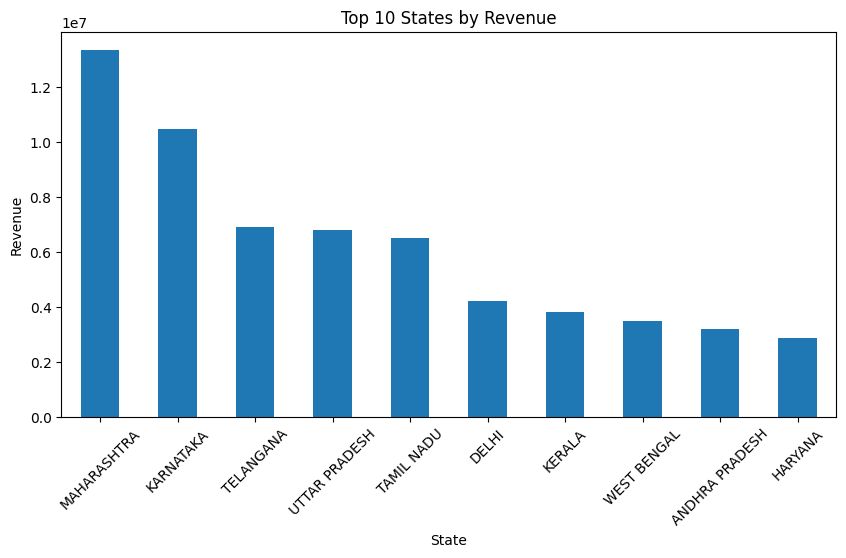

In [107]:
# Top 10 states by revenue
state_sales.head(10).plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [108]:
# Monthly revenue trend
df["Month"] = df["Date"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Amount"].sum()
monthly_sales

,Amount
Month,
2022-03,101683.85
2022-04,28826486.96
2022-05,26215581.75
2022-06,23412749.38


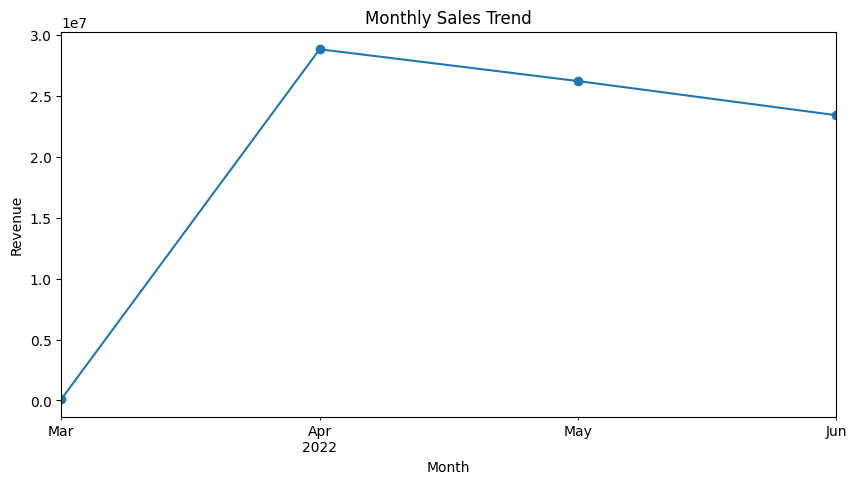

In [109]:
monthly_sales.plot(kind="line", figsize=(10, 5), marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [110]:
# Top 10 products by revenue
top_products = (
    df.groupby("SKU")["Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

,Amount
SKU,
J0230-SKD-M,527699.20
JNE3797-KR-L,524581.77
J0230-SKD-S,479937.14
JNE3797-KR-M,453555.16
JNE3797-KR-S,407302.57
JNE3797-KR-XL,332155.24
J0230-SKD-L,305616.95
JNE3797-KR-XS,303616.70
SET268-KR-NP-XL,284058.96


In [111]:
# Order status distribution
status_count = df["Status"].value_counts()
status_count

,count
Status,
Shipped,77751
Shipped - Delivered to Buyer,28764
Cancelled,18334
Shipped - Returned to Seller,1950
Shipped - Picked Up,973
Pending,658
Pending - Waiting for Pick Up,281
Shipped - Returning to Seller,145
Shipped - Out for Delivery,35


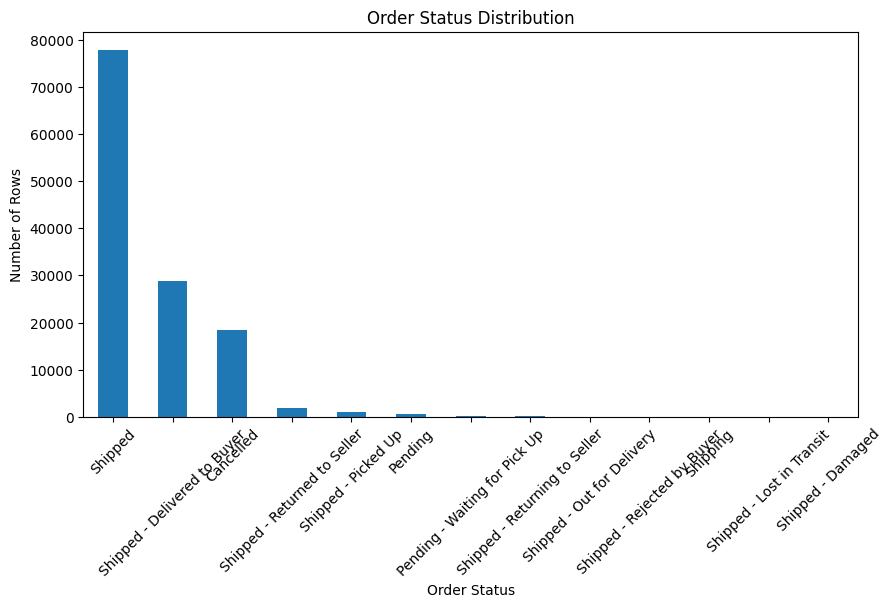

In [112]:
status_count.plot(kind="bar", figsize=(10, 5))
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Rows")
plt.xticks(rotation=45)
plt.show()

## 7. Phase 1B — Gross vs Net revenue (fix)

The first EDA summed `Amount` over **all** lines, including cancelled and returned ones. Real (net) revenue only counts orders that were actually completed. We group the 13 raw statuses into 4 business groups.

In [28]:
# PHASE 1B - GROSS vs NET REVENUE
COMPLETED = ["Shipped", "Shipped - Delivered to Buyer", "Shipped - Picked Up", "Shipped - Out for Delivery"]
RETURNED_OR_LOST = ["Shipped - Returned to Seller", "Shipped - Returning to Seller", "Shipped - Rejected by Buyer",
                    "Shipped - Lost in Transit", "Shipped - Damaged"]

def status_group(s):
    if s == "Cancelled":
        return "Cancelled"
    if s in RETURNED_OR_LOST:
        return "Returned / Lost"
    if s in COMPLETED:
        return "Completed"
    return "In progress"          # Pending / Shipping

df["status_group"] = df["Status"].map(status_group)

by_status = df.groupby("status_group").agg(order_lines=("Order ID", "size"), amount=("Amount", "sum"))
by_status["line_share_%"] = (100 * by_status["order_lines"] / by_status["order_lines"].sum()).round(1)
by_status["amount_share_%"] = (100 * by_status["amount"] / by_status["amount"].sum()).round(1)
display(by_status.round(0))

gross = df["Amount"].sum()
net = df.loc[df["status_group"] == "Completed", "Amount"].sum()
print(f"Gross revenue (what Phase 1 reported): Rs {gross:,.0f}")
print(f"Net revenue  (Completed only)        : Rs {net:,.0f}")
print(f"Overstatement                         : Rs {gross - net:,.0f}  ({(gross - net) / gross:.1%})")

fulfil = (df.groupby("Fulfilment")["status_group"]
            .agg(order_lines="size", cancel_rate=lambda s: (s == "Cancelled").mean(),
                 return_rate=lambda s: (s == "Returned / Lost").mean()).round(3))
display(fulfil)

,order_lines,amount,line_share_%,amount_share_%
status_group,,,,
Cancelled,18334,6924089.0,14.0,9.0
Completed,107523,69623941.0,83.0,89.0
In progress,947,622409.0,1.0,1.0
Returned / Lost,2112,1386063.0,2.0,2.0


Gross revenue (what Phase 1 reported): Rs 78,556,502
Net revenue  (Completed only)        : Rs 69,623,941
Overstatement                         : Rs 8,932,561  (11.4%)


,order_lines,cancel_rate,return_rate
Fulfilment,,,
Amazon,89659,0.128,0.000
Merchant,39257,0.175,0.054


**Reading it:** about **14% of order lines are cancelled** and a further ~1.6% are returned/lost, so the gross figure overstates real revenue by roughly **11%**. Merchant-fulfilled orders cancel more (17.5%) than Amazon-fulfilled ones (12.8%), and 5.4% of them end up returned/lost versus ~0% for Amazon-fulfilled — a concrete, actionable finding.

### ✅ Phase 1 takeaway
**Data cleaning + EDA show where revenue comes from — and, after the gross-vs-net fix, how much of it is real.** `Set` and `kurta` bring ~77% of gross revenue; Maharashtra is the top state; about 14% of order lines are cancelled, so net revenue (₹69.6M) is ~11% below gross (₹78.6M).

Next, the same business questions are reproduced in SQL.

### 🎤 INTERVIEW CARD — Phase 1 (Sales data cleaning + EDA)

| | |
|---|---|
| **Kyun** | Pehle samajhna ki business kaisa chal raha hai: revenue kahan se aa raha hai, kitne orders cancel ho rahe hain. |
| **Kya** | Input: Amazon-style order file (128,949 rows × 23 columns). Output: clean data (128,916 rows) + EDA. |
| **Kaise** | `Unnamed: 22` drop (Excel ka khali column). `currency` NaN → `INR` (ye wahi rows hain jahan Amount bhi NaN hai). 33 rows jinki shipping location missing thi drop ki. |
| **Result** | 120,324 orders, ₹78.56M gross. `Set` + `kurta` ≈ 77% revenue. Top state: Maharashtra (₹13.3M). **Net (sirf completed) = ₹69.6M**; 14.2% order lines cancelled; Merchant-fulfilled mein cancel 17.5% vs Amazon-fulfilled 12.8%, aur returned/lost 5.4% vs ~0%. |
| **Limit** | Sirf ~3 mahine ka data (31 Mar ek din ka stub hai). Is file mein **customer ID nahi hai**, isliye ye Ecommerce.csv se link nahi hoti — dono alag datasets hain. 6 exact duplicate rows hain jo rakhi gayi hain (alag items ki same order line ho sakti hai). |

**Interviewer poochhe to:**
- *Missing values ko kaise handle kiya?* → Blindly fill nahi kiya. Har column ke business meaning ke hisaab se decide kiya (jaise cancelled orders mein Amount NaN hona natural hai).
- *Gross aur net revenue mein fark?* → Gross mein cancelled/returned lines bhi judti hain. Net = sirf completed orders. Fark ₹8.9M (~11%).
- *Is analysis ka business action kya hai?* → Merchant fulfilment ki cancellation zyada hai → pehle wahan investigate karo.

# PHASE 2 — SQL & MYSQL BUSINESS ANALYTICS

The cleaned sales data is stored in **MySQL**:

- Database: `ecommerce_db`
- Table: `ecommerce_orders`
- Rows imported: **128,916**

These queries were executed in **MySQL Workbench**.

## SQL Query Reference

### 1. Business overview
```sql
SELECT
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(amount) AS total_revenue,
    SUM(qty) AS total_quantity
FROM ecommerce_orders;
```

### 2. Category revenue
```sql
SELECT
    category,
    SUM(amount) AS revenue
FROM ecommerce_orders
GROUP BY category
ORDER BY revenue DESC;
```

### 3. Top states
```sql
SELECT
    ship_state,
    SUM(amount) AS revenue
FROM ecommerce_orders
GROUP BY ship_state
ORDER BY revenue DESC
LIMIT 10;
```

### 4. Monthly revenue
```sql
SELECT
    DATE_FORMAT(date, '%Y-%m') AS month,
    SUM(amount) AS revenue
FROM ecommerce_orders
GROUP BY DATE_FORMAT(date, '%Y-%m')
ORDER BY month;
```

### 5. Category revenue for delivered/shipped orders
```sql
SELECT
    category,
    SUM(amount) AS revenue
FROM ecommerce_orders
WHERE status IN ('Shipped', 'Shipped - Delivered to Buyer')
GROUP BY category
ORDER BY revenue DESC;
```

### 6. CTE
```sql
WITH category_sales AS (
    SELECT
        category,
        SUM(amount) AS revenue
    FROM ecommerce_orders
    WHERE status IN ('Shipped', 'Shipped - Delivered to Buyer')
    GROUP BY category
)
SELECT *
FROM category_sales
WHERE revenue > 100000
ORDER BY revenue DESC;
```

### 7. Window function — product rank within category
```sql
SELECT
    category,
    sku,
    SUM(amount) AS revenue,
    RANK() OVER (
        PARTITION BY category
        ORDER BY SUM(amount) DESC
    ) AS product_rank
FROM ecommerce_orders
WHERE status IN ('Shipped', 'Shipped - Delivered to Buyer')
GROUP BY category, sku;
```

**SQL concepts covered:** `SELECT`, `WHERE`, `GROUP BY`, `HAVING`, `ORDER BY`, `LIMIT`, `CASE`, aggregations, CTE and window functions.

### Run the same SQL inside this notebook (sqlite) and prove it matches pandas
MySQL Workbench is where you ran the queries; this cell lets you re-run them anywhere (e.g. in an interview) and checks the numbers against pandas with `assert`.

In [29]:
import sqlite3

sql_df = df.drop(columns=["Month"], errors="ignore").copy()
sql_df.columns = [c.lower().replace("-", "_").replace(" ", "_") for c in sql_df.columns]
sql_df["date"] = sql_df["date"].dt.strftime("%Y-%m-%d")

con = sqlite3.connect(":memory:")
sql_df.to_sql("ecommerce_orders", con, index=False, if_exists="replace")
def q(sql):
    return pd.read_sql_query(sql, con)

# 1. overview
q1 = q("SELECT COUNT(DISTINCT order_id) AS total_orders, SUM(amount) AS total_revenue, SUM(qty) AS total_quantity FROM ecommerce_orders")
# 2. category revenue
q2 = q("SELECT category, SUM(amount) AS revenue FROM ecommerce_orders GROUP BY category ORDER BY revenue DESC")
# 3. top states
q3 = q("SELECT ship_state, SUM(amount) AS revenue FROM ecommerce_orders GROUP BY ship_state ORDER BY revenue DESC LIMIT 10")
# 4. monthly revenue (sqlite uses strftime instead of MySQL DATE_FORMAT)
q4 = q("SELECT strftime('%Y-%m', date) AS month, SUM(amount) AS revenue FROM ecommerce_orders GROUP BY month ORDER BY month")
# 5. completed-only category revenue
q5 = q("""SELECT category, SUM(amount) AS revenue FROM ecommerce_orders
          WHERE status IN ('Shipped', 'Shipped - Delivered to Buyer') GROUP BY category ORDER BY revenue DESC""")
# 6. CTE
q6 = q("""WITH category_sales AS (
              SELECT category, SUM(amount) AS revenue FROM ecommerce_orders
              WHERE status IN ('Shipped', 'Shipped - Delivered to Buyer') GROUP BY category)
          SELECT * FROM category_sales WHERE revenue > 100000 ORDER BY revenue DESC""")
# 7. window function: top 3 SKUs inside each category
q7 = q("""WITH ranked AS (
              SELECT category, sku, SUM(amount) AS revenue,
                     RANK() OVER (PARTITION BY category ORDER BY SUM(amount) DESC) AS product_rank
              FROM ecommerce_orders WHERE status IN ('Shipped', 'Shipped - Delivered to Buyer')
              GROUP BY category, sku)
          SELECT * FROM ranked WHERE product_rank <= 3 ORDER BY category, product_rank""")

# ---- the SQL numbers must equal the pandas numbers
assert q1["total_orders"][0] == df["Order ID"].nunique()
assert abs(q1["total_revenue"][0] - df["Amount"].sum()) < 1
pd_cat = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
assert abs(q2.set_index("category")["revenue"] - pd_cat).max() < 1
pd_cat_done = df[df["Status"].isin(["Shipped", "Shipped - Delivered to Buyer"])].groupby("Category")["Amount"].sum()
assert abs(q5.set_index("category")["revenue"] - pd_cat_done).max() < 1
print("SQL results match pandas ✅")
display(q1); display(q2.head()); display(q4); display(q7.head(9))

SQL results match pandas ✅


,total_orders,total_revenue,total_quantity
0,120324,78556501.94,116623


,category,revenue
0,Set,39187138.67
1,kurta,21287124.70
2,Western Dress,11211688.69
3,Top,5346262.30
4,Ethnic Dress,790362.66


,month,revenue
0,2022-03,101683.85
1,2022-04,28826486.96
2,2022-05,26215581.75
3,2022-06,23412749.38


,category,sku,revenue,product_rank
0,Blouse,J0217-BL-L,20275.0,1
1,Blouse,J0217-BL-M,19593.0,2
2,Blouse,J0217-BL-XL,18922.0,3
3,Bottom,BTM031-NP-XL,2590.0,1
4,Bottom,BTM039-PP-XXXL,2520.0,2
5,Bottom,BTM002-B-M,2283.0,3
6,Dupatta,DPT052,305.0,1
7,Dupatta,DPT041,305.0,1
8,Dupatta,DPT032,305.0,1


In [113]:
# Optional: regenerate the cleaned CSV used for the MySQL import

df.to_csv("clean_ecommerce_data.csv", index=False)
print("Saved: clean_ecommerce_data.csv ✅")

Saved: clean_ecommerce_data.csv ✅


### 🎤 INTERVIEW CARD — Phase 2 (SQL)

| | |
|---|---|
| **Kyun** | Analyst ko data database se nikalna aana chahiye, sirf pandas se nahi. |
| **Kya** | Wahi business questions SQL mein: overview, category, state, month, CTE, window function. |
| **Kaise** | MySQL Workbench mein run kiye. Upar wale cell mein **wahi queries sqlite par bhi run** hoti hain aur pandas ke numbers se `assert` se match karti hain — yani aap kabhi bhi live prove kar sakte ho. |
| **Result** | SQL aur pandas dono ka total revenue / category revenue exactly same. |
| **Limit** | Query 1–4 mein cancelled orders bhi count hote hain (gross). Query 5–7 mein sirf Shipped/Delivered filter hai (net-jaisa). |

**Interviewer poochhe to:**
- *`WHERE` aur `HAVING` mein fark?* → WHERE group banne se **pehle** rows filter karta hai; HAVING group banne ke **baad** groups filter karta hai.
- *`RANK()` vs `ROW_NUMBER()`?* → Tie par RANK same rank deta hai (aur agla number skip hota hai); ROW_NUMBER hamesha unique number.
- *CTE kyun?* → Query ko padhne layak banane ke liye (ek temporary named result), complex subqueries ki jagah.

# PHASE 3 — CUSTOMER INTELLIGENCE

## Customer Behaviour Dataset
- Rows: **25,000**
- Columns: **29**
- Includes customer/session behaviour, purchases, cart activity, reviews, marketing channels and location.

**Purpose:** Build the customer-level intelligence required for segmentation, prediction and personalization.

In [114]:
from google.colab import files

# Upload Ecommerce.csv
uploaded = files.upload()

Saving Ecommerce.csv to Ecommerce (1).csv


In [115]:
customer_df1 = pd.read_csv("Ecommerce.csv")

print("Shape:", customer_df1.shape)
print("Columns:", customer_df1.columns.tolist())

Shape: (25000, 29)
Columns: ['customer_id', 'session_id', 'visit_date', 'device_type', 'user_type', 'marketing_channel', 'product_id', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'revenue', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased', 'cart_abandoned', 'rating', 'review_text', 'review_helpful_votes', 'payment_method', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'session_duration_bucket', 'revenue_normalized', 'location']


In [116]:
# Data types and missing values
customer_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              25000 non-null  int64  
 1   session_id               25000 non-null  int64  
 2   visit_date               25000 non-null  object 
 3   device_type              25000 non-null  int64  
 4   user_type                25000 non-null  int64  
 5   marketing_channel        25000 non-null  int64  
 6   product_id               25000 non-null  int64  
 7   product_category         25000 non-null  int64  
 8   unit_price               25000 non-null  float64
 9   quantity                 25000 non-null  int64  
 10  discount_percent         25000 non-null  int64  
 11  discount_amount          25000 non-null  float64
 12  revenue                  25000 non-null  float64
 13  pages_viewed             25000 non-null  int64  
 14  time_on_site_sec      

In [117]:
# Missing values
customer_df1.isnull().sum()

,0
customer_id,0
session_id,0
visit_date,0
device_type,0
user_type,0
marketing_channel,0
product_id,0
product_category,0
unit_price,0
quantity,0


## 1. Customer 360

**Purpose:** Convert session-level records into one summary profile per customer.

In [118]:
customer_df1["visit_date"] = pd.to_datetime(customer_df1["visit_date"], format="%d-%m-%Y")   # explicit day-first (dd-mm-yyyy)

customer_360 = customer_df1.groupby("customer_id").agg(
    total_sessions=("session_id", "nunique"),
    total_revenue=("revenue", "sum"),
    total_quantity=("quantity", "sum"),
    total_purchases=("purchased", "sum"),
    avg_pages_viewed=("pages_viewed", "mean"),
    avg_time_on_site=("time_on_site_sec", "mean"),
    total_cart_adds=("added_to_cart", "sum"),
    total_cart_abandoned=("cart_abandoned", "sum"),
    avg_rating=("rating", "mean"),
    last_visit=("visit_date", "max")
).reset_index()

customer_360.head()

,customer_id,total_sessions,total_revenue,total_quantity,total_purchases,avg_pages_viewed,avg_time_on_site,total_cart_adds,total_cart_abandoned,avg_rating,last_visit
0,1000,2,1228.72,7,1,17.500000,1014.000000,2,1,3.500000,2024-06-18
1,1001,1,0.00,4,0,15.000000,996.000000,0,0,4.000000,2024-12-21
2,1002,3,0.00,8,0,8.333333,313.666667,2,2,4.000000,2024-11-04
3,1003,3,1681.96,9,1,5.666667,695.333333,1,0,4.333333,2024-12-04
4,1004,3,0.00,5,0,12.333333,923.666667,1,1,4.000000,2024-09-27


**Data-quality fix:** `rating` is filled with a default **4** for sessions without a purchase, so `avg_rating` above is polluted. We add `avg_rating_genuine` (buyers only) and use that from now on.

In [36]:
genuine_rating = (customer_df1[customer_df1["purchased"] == 1]
                  .groupby("customer_id")["rating"].mean().rename("avg_rating_genuine").reset_index())
customer_360 = customer_360.merge(genuine_rating, on="customer_id", how="left")

print("avg_rating (includes the default 4 for non-buyers):", round(customer_360["avg_rating"].mean(), 2))
print("avg_rating_genuine (buyers only)                  :", round(customer_360["avg_rating_genuine"].mean(), 2))
print("customers:", len(customer_360), "| with a genuine rating:", customer_360["avg_rating_genuine"].notna().sum())
customer_360.head()

avg_rating (includes the default 4 for non-buyers): 3.95
avg_rating_genuine (buyers only)                  : 3.76
customers: 8442 | with a genuine rating: 4176


,customer_id,total_sessions,total_revenue,total_quantity,total_purchases,avg_pages_viewed,avg_time_on_site,total_cart_adds,total_cart_abandoned,avg_rating,last_visit,avg_rating_genuine
0,1000,2,1228.72,7,1,17.500000,1014.000000,2,1,3.500000,2024-06-18,3.0
1,1001,1,0.00,4,0,15.000000,996.000000,0,0,4.000000,2024-12-21,NaN
2,1002,3,0.00,8,0,8.333333,313.666667,2,2,4.000000,2024-11-04,NaN
3,1003,3,1681.96,9,1,5.666667,695.333333,1,0,4.333333,2024-12-04,5.0
4,1004,3,0.00,5,0,12.333333,923.666667,1,1,4.000000,2024-09-27,NaN


### Customer 360 gives us

| Metric | Meaning |
|---|---|
| Total sessions | How often the customer visited |
| Total revenue | Customer value generated so far |
| Total purchases | Purchase behaviour |
| Pages/time | Engagement |
| Cart abandonment | Purchase intent signal |
| Rating | Satisfaction signal |
| Last visit | Recent activity |

### 🎤 INTERVIEW CARD — Phase 3 (Customer 360)

| | |
|---|---|
| **Kyun** | Data session-level hai (25,000 rows). Marketing customer-level par hoti hai. |
| **Kya** | Input: `Ecommerce.csv` (25,000 sessions × 29 columns). Output: har customer ki ek row (8,442 customers). |
| **Kaise** | `groupby("customer_id").agg(...)`: sessions, revenue, purchases, cart adds, abandoned carts, last visit. |
| **Result** | Sirf ~4,176 customers (~50%) ne kabhi kuch kharida. Baaki ya to cart chhod gaye ya sirf browse kiya. |
| **Limit** | `rating` column mein non-buyers ko default **4** diya gaya hai, isliye `avg_rating` jhootha hai. Isiliye `avg_rating_genuine` (sirf buyers) alag banaya gaya hai. |

**Interviewer poochhe to:**
- *Customer 360 kya hota hai?* → Ek customer ki saari activity ek row mein, taaki segmentation/model customer-level par ho sake.
- *Aapne data mein kaunsi gadbad pakdi?* → Rating ka default 4 — 78% rows ka rating asli nahi hai.

# PHASE 4 — CORRECT RFM ANALYSIS

### Why are we redoing RFM?
The first version used **last visit** for Recency. For a true purchase-based RFM analysis, Recency should be based on the **last actual purchase**.

### RFM
- **R — Recency:** days since last purchase
- **F — Frequency:** number of purchases
- **M — Monetary:** total purchase revenue

We will rebuild RFM using only actual purchase records.

In [119]:
# Keep only actual purchase records
purchase_data = customer_df1[customer_df1["purchased"] == 1].copy()

# Reference date = one day after the last date in the dataset
reference_date = customer_df1["visit_date"].max() + pd.Timedelta(days=1)

# Build purchase-based RFM table
rfm_corrected = purchase_data.groupby("customer_id").agg(
    last_purchase=("visit_date", "max"),
    frequency=("purchased", "sum"),
    monetary=("revenue", "sum")
).reset_index()

# Recency in days
rfm_corrected["recency"] = (
    reference_date - rfm_corrected["last_purchase"]
).dt.days

rfm_corrected[[
    "customer_id", "recency", "frequency", "monetary"
]].head()

,customer_id,recency,frequency,monetary
0,1000,248,1,1228.72
1,1003,89,1,1681.96
2,1008,49,1,1546.42
3,1009,100,3,4616.63
4,1014,318,1,2423.92


### What we expect

Only customers who actually purchased are used in purchase-based RFM. Customers with no purchase will be handled separately as **non-buyers** rather than giving them an artificial purchase Recency.

In [120]:
# Create RFM scores for purchasing customers
rfm_corrected["R_score"] = pd.qcut(
    rfm_corrected["recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm_corrected["F_score"] = pd.qcut(
    rfm_corrected["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm_corrected["M_score"] = pd.qcut(
    rfm_corrected["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm_corrected["RFM_score"] = (
    rfm_corrected["R_score"] +
    rfm_corrected["F_score"] +
    rfm_corrected["M_score"]
)

rfm_corrected.head()

,customer_id,last_purchase,frequency,monetary,recency,R_score,F_score,M_score,RFM_score
0,1000,2024-04-27,1,1228.72,248,2,1,2,5
1,1003,2024-10-03,1,1681.96,89,4,1,3,8
2,1008,2024-11-12,1,1546.42,49,5,1,3,9
3,1009,2024-09-22,3,4616.63,100,4,5,5,14
4,1014,2024-02-17,1,2423.92,318,1,1,4,6


### 🎤 INTERVIEW CARD — Phase 4 (RFM)

| | |
|---|---|
| **Kyun** | Batana ki kaun customer kitna "valuable" hai. |
| **Kya** | **R**ecency = last *purchase* ko kitne din hue; **F**requency = kitni purchases; **M**onetary = kul kharcha. |
| **Kaise** | Sirf `purchased == 1` rows se. Reference date = dataset ki last date + 1 din. |
| **Result** | 4,176 buyers ka RFM table. |
| **Limit** | Pehla version "last *visit*" par bana tha jo galat tha (visit ≠ purchase) — isliye dobara banaya. Frequency sirf 1–5 ke beech hai, isliye RFM zyada tar recency aur monetary se chalta hai. |

**Interviewer poochhe to:**
- *Recency ke liye last visit kyun galat tha?* → Koi visit karke kuch na khareede to wo "recent customer" nahi hai.

## 5. ML Segmentation — K-Means (NEXT)

Once the corrected RFM table is checked, K-Means will use:

**Recency + Frequency + Monetary → Scaling → K-Means → Behaviour clusters**

> The earlier K-Means result based on visit-based Recency is treated as an old experiment and will **not** be used as the final result.

In [121]:
# Prepare RFM features for K-Means
rfm_data = rfm_corrected[["recency", "frequency", "monetary"]]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

print("RFM features scaled ✅")

RFM features scaled ✅


In [122]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm_corrected["kmeans_cluster"] = kmeans.fit_predict(rfm_scaled)

rfm_corrected[[
    "customer_id",
    "recency",
    "frequency",
    "monetary",
    "kmeans_cluster"
]].head(10)

,customer_id,recency,frequency,monetary,kmeans_cluster
0,1000,248,1,1228.72,0
1,1003,89,1,1681.96,2
2,1008,49,1,1546.42,2
3,1009,100,3,4616.63,3
4,1014,318,1,2423.92,0
5,1026,350,1,244.30,0
6,1028,138,1,2328.44,2
7,1029,155,1,357.02,2
8,1031,129,2,2231.42,1
9,1033,333,1,571.06,0


In [123]:
# Cluster profile
cluster_profile = rfm_corrected.groupby("kmeans_cluster")[
    ["recency", "frequency", "monetary"]
].mean().round(2)

cluster_profile

,recency,frequency,monetary
kmeans_cluster,,,
0,281.18,1.03,1881.76
1,111.93,2.10,2748.51
2,96.90,1.00,1751.59
3,102.00,2.56,6960.44


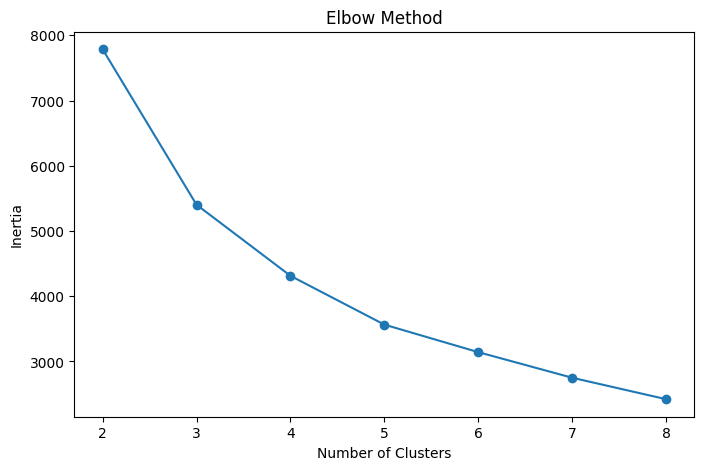

In [124]:
# Elbow Method
from sklearn.metrics import silhouette_score

inertia = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [125]:
# Silhouette Score for the current 4-cluster solution
score = silhouette_score(
    rfm_scaled,
    rfm_corrected["kmeans_cluster"]
)

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.391


### 5.1 Choosing k and naming the segments

Silhouette says k=2 is the "cleanest" split, but two groups are too few to drive different marketing actions.
We keep **k = 4** (Silhouette ≈ 0.39 — acceptable) because it gives four actionable segments. A name is assigned by rule from the cluster profile, so the names stay correct even if cluster numbers change.

In [126]:
# Silhouette for k = 2..8 (higher = better separated)
sil = {}
for k in range(2, 9):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(rfm_scaled)
    sil[k] = round(silhouette_score(rfm_scaled, labels), 3)
print("Silhouette by k:", sil)

# Name clusters from their RFM profile (rule-based, not hand-typed)
profile = rfm_corrected.groupby("kmeans_cluster")[["recency", "frequency", "monetary"]].mean()
left, names = set(profile.index), {}
for col, label in [("monetary",  "Champions (High Value)"),
                   ("recency",   "Lapsed Buyers (At Risk)"),
                   ("frequency", "Loyal Repeat Buyers")]:
    idx = profile.loc[sorted(left), col].idxmax()
    names[idx] = label
    left.discard(idx)
for idx in left:
    names[idx] = "Recent One-Time Buyers"

rfm_corrected["segment"] = rfm_corrected["kmeans_cluster"].map(names)

segment_summary = (rfm_corrected.groupby("segment")
    .agg(customers=("customer_id", "count"),
         avg_recency_days=("recency", "mean"),
         avg_frequency=("frequency", "mean"),
         avg_monetary=("monetary", "mean"),
         total_revenue=("monetary", "sum"))
    .round(1).sort_values("total_revenue", ascending=False))
segment_summary["revenue_share_%"] = (100 * segment_summary["total_revenue"] / segment_summary["total_revenue"].sum()).round(1)
segment_summary

Silhouette by k: {2: np.float64(0.419), 3: np.float64(0.365), 4: np.float64(0.391), 5: np.float64(0.399), 6: np.float64(0.393), 7: np.float64(0.357), 8: np.float64(0.372)}


,customers,avg_recency_days,avg_frequency,avg_monetary,total_revenue,revenue_share_%
segment,,,,,,
Recent One-Time Buyers,1587,96.9,1.0,1751.6,2779780.7,27.5
Lapsed Buyers (At Risk),1461,281.2,1.0,1881.8,2749256.0,27.2
Champions (High Value),353,102.0,2.6,6960.4,2457033.8,24.3
Loyal Repeat Buyers,775,111.9,2.1,2748.5,2130098.6,21.1


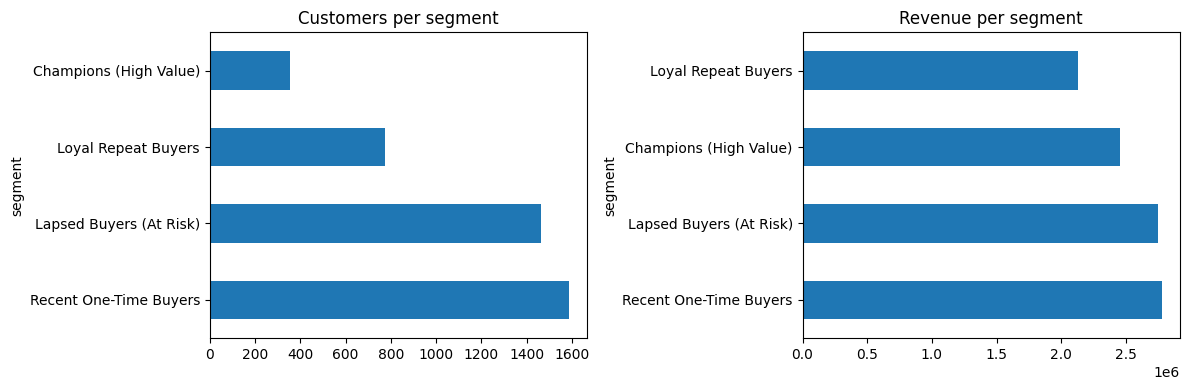

In [127]:
# Segment size vs revenue
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
rfm_corrected["segment"].value_counts().plot(kind="barh", ax=ax[0], title="Customers per segment")
segment_summary["total_revenue"].plot(kind="barh", ax=ax[1], title="Revenue per segment")
plt.tight_layout(); plt.show()

### ✅ Phase 5 takeaway
- **Champions** are a small group that brings a disproportionately large share of buyer revenue → protect them with perks, not discounts.
- **Lapsed Buyers** (long recency) are the win-back target.
- Only **~50% of customers have ever bought**. The other half (cart abandoners + pure browsers) are handled as separate segments in the customer master table later.

### 🎤 INTERVIEW CARD — Phase 5 (K-Means segmentation)

| | |
|---|---|
| **Kyun** | 4,176 buyers ko alag-alag marketing action dene ke liye groups chahiye. |
| **Kya** | Input: R, F, M. Output: 4 named segments. |
| **Kaise** | `StandardScaler` (kyunki ₹ aur din alag scale par hain) → `KMeans(n_clusters=4)`. k ka chunav: Elbow + Silhouette. Naam rule se diye (profile se), haath se nahi. |
| **Result** | Recent One-Time (1,587), Lapsed (1,461), Loyal Repeat (775), Champions (353 ≈ 8.5% buyers). Silhouette = 0.391. |
| **Limit** | Silhouette k=2 par sabse zyada (0.419) hai, k=5 par 0.399. Humne k=4 isliye rakha ki 4 groups = 4 alag business action (difference chhota hai). K-Means round clusters maanta hai; segments *descriptive* hain, "sach" nahi. |

**Interviewer poochhe to:**
- *Scaling kyun?* → Warna ₹ (hazaaron) distance par haavi ho jaata aur din/frequency ka asar khatam.
- *Elbow vs Silhouette?* → Elbow = inertia ka mod; Silhouette = clusters kitne alag hain (−1 se 1).
- *k kaise chuna?* → Statistic + business: k=2 se alag campaigns nahi ban sakte.

# PHASE 6 — PURCHASE PREDICTION (EXPERIMENT LOG)

The first purchase-propensity experiment was completed earlier using the session-level customer dataset.

### Final tested approach
- XGBoost with class balancing
- Threshold tuning
- Working threshold tested: **0.35**
- Precision: **34.7%**
- Recall: **97.2%**
- F1: **51.1%**
- ROC-AUC: **0.749**
- PR-AUC: **0.386**

### Decision
This is kept as an **experiment/result**, not treated as the final production model yet. We will refine the prediction problem after the corrected customer segmentation and recommendation workflow are stable.

# ❌ REMOVED FROM FINAL FLOW — CUSTOMER VALUE REGRESSION

The earlier future-revenue regression experiments produced negative R² values:

- Log-target XGBoost: **R² = -0.227**
- Direct-target XGBoost: **R² = -0.195**

### Decision
The regression experiment is **not part of the final project flow**. We keep the result as a learning note and will use regression only when we have a clearly defined, well-supported e-commerce business problem.

# ✅ COMPLETION LOG

1. ~~Correct RFM~~ ✅  2. ~~K-Means~~ ✅  3. ~~Recommender (+baselines)~~ ✅  4. ~~Reviews / sentiment~~ ✅
5. ~~Policy engine + LLM writer + guardrails~~ ✅ (Phase 9)  6. ~~Streamlit + Flask files~~ ✅ (Phase 10)  7. ~~BI exports~~ ✅ (Phase 11)
8. **You:** build the Power BI / Tableau dashboard from `bi_exports/`  9. **You:** push to GitHub and deploy (Phase 12)

> **Rule:** every module must solve a real e-commerce problem and connect to the previous module.

# # PHASE 6 — PURCHASE PROPENSITY MODEL

**Goal:** Predict the probability that a customer will make a purchase using only information available before the purchase decision.

**Business Use:** Use purchase probability together with customer segments to support personalized marketing decisions.

Step 1 - Features + Target

In [128]:
# PHASE 6 — PURCHASE PROPENSITY MODEL
# X = customer/session behaviour
# y = actual purchase (0 = No, 1 = Yes)

X_purchase = customer_df1[
    [
        "unit_price",
        "quantity",
        "discount_percent",
        "pages_viewed",
        "time_on_site_sec",
        "added_to_cart",
        "device_type",
        "user_type",
        "marketing_channel"
    ]
]

y_purchase = customer_df1["purchased"]

print("X shape:", X_purchase.shape)
print("y shape:", y_purchase.shape)

X shape: (25000, 9)
y shape: (25000,)


## Train/Test Split + Preprocessing karenge.

In [129]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical columns
numeric_features = [
    "unit_price",
    "quantity",
    "discount_percent",
    "pages_viewed",
    "time_on_site_sec",
    "added_to_cart"
]

# Categorical columns
categorical_features = [
    "device_type",
    "user_type",
    "marketing_channel"
]

# Split data: 80% training, 20% testing
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_purchase,
    y_purchase,
    test_size=0.20,
    random_state=42,
    stratify=y_purchase
)

# Preprocessing
preprocessor_purchase = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Training data:", X_train_p.shape)
print("Testing data:", X_test_p.shape)

Training data: (20000, 9)
Testing data: (5000, 9)


In [130]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Preprocessing + Logistic Regression
logistic_purchase = Pipeline([
    ("preprocessor", preprocessor_purchase),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000
    ))
])

# Train
logistic_purchase.fit(X_train_p, y_train_p)

print("Logistic Regression trained ✅")

Logistic Regression trained ✅


In [131]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Test data par prediction
y_pred_p = logistic_purchase.predict(X_test_p)

print("Accuracy :", round(accuracy_score(y_test_p, y_pred_p), 3))
print("Precision:", round(precision_score(y_test_p, y_pred_p), 3))
print("Recall   :", round(recall_score(y_test_p, y_pred_p), 3))
print("F1 Score :", round(f1_score(y_test_p, y_pred_p), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_p, y_pred_p))

Accuracy : 0.573
Precision: 0.344
Recall   : 1.0
F1 Score : 0.512

Confusion Matrix:
[[1740 2137]
 [   0 1123]]


# XG-Boost

In [132]:
from xgboost import XGBClassifier

# Purchase classes ka balance handle karne ke liye
scale_pos_weight = (
    (y_train_p == 0).sum() /
    (y_train_p == 1).sum()
)

xgb_purchase = Pipeline([
    ("preprocessor", preprocessor_purchase),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_purchase.fit(X_train_p, y_train_p)

print("XGBoost trained ✅")

XGBoost trained ✅


In [133]:
# XGBoost predictions
y_pred_xgb = xgb_purchase.predict(X_test_p)

print("Accuracy :", round(accuracy_score(y_test_p, y_pred_xgb), 3))
print("Precision:", round(precision_score(y_test_p, y_pred_xgb), 3))
print("Recall   :", round(recall_score(y_test_p, y_pred_xgb), 3))
print("F1 Score :", round(f1_score(y_test_p, y_pred_xgb), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_p, y_pred_xgb))

Accuracy : 0.617
Precision: 0.354
Recall   : 0.857
F1 Score : 0.501

Confusion Matrix:
[[2121 1756]
 [ 161  962]]


In [134]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Purchase probability
y_prob_xgb = xgb_purchase.predict_proba(X_test_p)[:, 1]

# AUC scores
roc_auc = roc_auc_score(y_test_p, y_prob_xgb)
pr_auc = average_precision_score(y_test_p, y_prob_xgb)

print("ROC-AUC:", round(roc_auc, 3))
print("PR-AUC :", round(pr_auc, 3))


# Different probability thresholds
threshold_results = []

for threshold in np.arange(0.20, 0.81, 0.05):
    pred = (y_prob_xgb >= threshold).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": round(precision_score(y_test_p, pred), 3),
        "recall": round(recall_score(y_test_p, pred), 3),
        "f1": round(f1_score(y_test_p, pred), 3)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results


ROC-AUC: 0.749
PR-AUC : 0.386


,threshold,precision,recall,f1
0,0.20,0.343,0.990,0.510
1,0.25,0.344,0.988,0.511
2,0.30,0.344,0.981,0.510
3,0.35,0.347,0.972,0.511
4,0.40,0.348,0.947,0.509
5,0.45,0.352,0.921,0.509
6,0.50,0.354,0.857,0.501
7,0.55,0.362,0.772,0.493
8,0.60,0.364,0.632,0.462
9,0.65,0.381,0.483,0.426


In [135]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# Training data ka ek validation part alag kar rahe hain
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_p,
    y_train_p,
    test_size=0.20,
    random_state=42,
    stratify=y_train_p
)

# Different class-balance values test karenge
weights = [2.0, 2.5, 3.0, 3.45]

results = []

for weight in weights:

    model = Pipeline([
        ("preprocessor", preprocessor_purchase),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            scale_pos_weight=weight,
            random_state=42,
            eval_metric="logloss"
        ))
    ])

    model.fit(X_tr, y_tr)

    pred = model.predict(X_val)

    results.append({
        "weight": weight,
        "accuracy": round(accuracy_score(y_val, pred), 3),
        "precision": round(precision_score(y_val, pred), 3),
        "recall": round(recall_score(y_val, pred), 3),
        "f1": round(f1_score(y_val, pred), 3)
    })

tuning_results = pd.DataFrame(results)

tuning_results

,weight,accuracy,precision,recall,f1
0,2.00,0.701,0.391,0.590,0.470
1,2.50,0.661,0.374,0.751,0.499
2,3.00,0.635,0.368,0.874,0.518
3,3.45,0.619,0.363,0.928,0.522


In [136]:
# Weight = 3.0 ka model
best_xgb = Pipeline([
    ("preprocessor", preprocessor_purchase),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=3.0,
        random_state=42,
        eval_metric="logloss"
    ))
])

# Validation data par train
best_xgb.fit(X_tr, y_tr)

# Purchase probability
y_prob_val = best_xgb.predict_proba(X_val)[:, 1]

# Different thresholds test
threshold_results = []

for threshold in np.arange(0.20, 0.81, 0.05):
    pred = (y_prob_val >= threshold).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": round(precision_score(y_val, pred), 3),
        "recall": round(recall_score(y_val, pred), 3),
        "f1": round(f1_score(y_val, pred), 3)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,threshold,precision,recall,f1
0,0.20,0.358,0.998,0.527
1,0.25,0.359,0.998,0.528
2,0.30,0.358,0.992,0.527
3,0.35,0.359,0.988,0.527
4,0.40,0.361,0.976,0.527
5,0.45,0.363,0.947,0.525
6,0.50,0.368,0.874,0.518
7,0.55,0.376,0.732,0.497
8,0.60,0.394,0.582,0.470
9,0.65,0.381,0.364,0.372


In [137]:
from sklearn.metrics import balanced_accuracy_score

threshold_check = []

for threshold in np.arange(0.20, 0.81, 0.05):
    pred = (y_prob_val >= threshold).astype(int)

    threshold_check.append({
        "threshold": round(threshold, 2),
        "accuracy": round(accuracy_score(y_val, pred), 3),
        "balanced_accuracy": round(
            balanced_accuracy_score(y_val, pred), 3
        ),
        "precision": round(precision_score(y_val, pred), 3),
        "recall": round(recall_score(y_val, pred), 3),
        "f1": round(f1_score(y_val, pred), 3)
    })

threshold_check = pd.DataFrame(threshold_check)

threshold_check

,threshold,accuracy,balanced_accuracy,precision,recall,f1
0,0.20,0.598,0.740,0.358,0.998,0.527
1,0.25,0.599,0.741,0.359,0.998,0.528
2,0.30,0.599,0.739,0.358,0.992,0.527
3,0.35,0.602,0.739,0.359,0.988,0.527
4,0.40,0.606,0.737,0.361,0.976,0.527
5,0.45,0.615,0.733,0.363,0.947,0.525
6,0.50,0.635,0.720,0.368,0.874,0.518
7,0.55,0.667,0.690,0.376,0.732,0.497
8,0.60,0.705,0.661,0.394,0.582,0.470
9,0.65,0.724,0.596,0.381,0.364,0.372


In [138]:
# Final XGBoost model
final_xgb = Pipeline([
    ("preprocessor", preprocessor_purchase),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=3.0,
        random_state=42,
        eval_metric="logloss"
    ))
])

# Full training data par final model train
final_xgb.fit(X_train_p, y_train_p)

# Test-set probabilities
y_prob_final = final_xgb.predict_proba(X_test_p)[:, 1]

# Working threshold = 0.35
y_pred_final = (y_prob_final >= 0.35).astype(int)

print("Final Accuracy :", round(accuracy_score(y_test_p, y_pred_final), 3))
print("Final Precision:", round(precision_score(y_test_p, y_pred_final), 3))
print("Final Recall   :", round(recall_score(y_test_p, y_pred_final), 3))
print("Final F1 Score :", round(f1_score(y_test_p, y_pred_final), 3))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_p, y_pred_final))

Final Accuracy : 0.574
Final Precision: 0.344
Final Recall   : 0.991
Final F1 Score : 0.511

Confusion Matrix:
[[1759 2118]
 [  10 1113]]


# Phase 6 status — experiment finished, **see 6B for the honest re-evaluation**

The XGBoost experiment above is kept as a learning record. Its headline numbers (Recall 0.99, ROC-AUC 0.75) look good **only because** the model uses `added_to_cart`, and a customer cannot buy without adding to cart — so most of that AUC is just the funnel stage. Precision of 34% and 2,118 false positives show the model is not actually separating buyers from non-buyers. Phase 6B proves this with numbers.

# PHASE 6B — HONEST PURCHASE-PREDICTION AUDIT

**Goal in this section:** find out *how accurate a purchase model can honestly be on this dataset*, and why "0 false positives and 0 false negatives" cannot be reached with real pre-purchase information.

Steps: (1) leakage audit → (2) show what a "perfect" model looks like and why it is fake → (3) honest two-stage model → (4) how to use it in business.

### 6B.1 Leakage audit — which columns exist *before* the purchase decision?

In [139]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def single_feature_auc(col, target="purchased", data=customer_df1):
    """Cross-validated AUC of a tiny tree that sees ONE column only."""
    p = cross_val_predict(DecisionTreeClassifier(max_depth=4, random_state=42),
                          data[[col]], data[target], cv=cv5, method="predict_proba")[:, 1]
    return roc_auc_score(data[target], p)

when_known = {
    "unit_price": "before", "quantity": "before", "discount_percent": "before",
    "pages_viewed": "before", "time_on_site_sec": "before", "device_type": "before",
    "user_type": "before", "marketing_channel": "before", "payment_method": "before",
    "added_to_cart":        "before (funnel stage - real, but prerequisite of purchase)",
    "cart_abandoned":       "AFTER  (=1 only when the cart was NOT bought)",
    "rating":               "AFTER  (non-buyers all carry a default of 4)",
    "review_text":          "AFTER  (only buyers write reviews)",
    "review_helpful_votes": "AFTER  (votes come after a review exists)",
    "revenue":              "AFTER  (= 0 unless purchased)",
    "revenue_normalized":   "AFTER  (= scaled revenue)",
}
audit = pd.DataFrame({"feature": list(when_known),
                      "single_feature_AUC": [round(single_feature_auc(c), 3) for c in when_known],
                      "known_when": list(when_known.values())}
                     ).sort_values("single_feature_AUC", ascending=False)
audit

,feature,single_feature_AUC,known_when
15,revenue_normalized,1.000,AFTER (= scaled revenue)
14,revenue,1.000,AFTER (= 0 unless purchased)
13,review_helpful_votes,0.988,AFTER (votes come after a review exists)
12,review_text,0.899,AFTER (only buyers write reviews)
11,rating,0.820,AFTER (non-buyers all carry a default of 4)
10,cart_abandoned,0.770,AFTER (=1 only when the cart was NOT bought)
9,added_to_cart,0.728,"before (funnel stage - real, but prerequisite ..."
6,user_type,0.546,before
4,time_on_site_sec,0.516,before
0,unit_price,0.506,before


**Reading the table:** every "before" feature has AUC ≈ 0.50 on its own (= coin flip). Only the *after-the-fact* columns (revenue, helpful votes, review, rating) look strong — because they are the outcome in disguise.

### 6B.2 The trap — a "perfect" model that is useless

In [140]:
from sklearn.ensemble import HistGradientBoostingClassifier

leaky_cols = ["rating", "review_text", "review_helpful_votes", "cart_abandoned", "revenue"]
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(customer_df1[leaky_cols], customer_df1["purchased"],
                                              test_size=0.2, random_state=42, stratify=customer_df1["purchased"])
leaky = HistGradientBoostingClassifier(random_state=42).fit(Xl_tr, yl_tr)
pl = leaky.predict(Xl_te)

print("Accuracy :", round(accuracy_score(yl_te, pl), 4))
print("ROC-AUC  :", round(roc_auc_score(yl_te, leaky.predict_proba(Xl_te)[:, 1]), 4))
print("Confusion matrix (rows=actual, cols=predicted):")
print(confusion_matrix(yl_te, pl))

Accuracy : 1.0
ROC-AUC  : 1.0
Confusion matrix (rows=actual, cols=predicted):
[[3877    0]
 [   0 1123]]


This is the "0 false positive / 0 false negative" result — and it is **worthless**. `revenue > 0` simply *is* "purchased". At the moment you need a prediction (the customer is still browsing), revenue, rating and review do not exist yet. **Never report this model.**

### 6B.3 Honest model — the purchase funnel in two stages

Browse → **Add to cart** → **Purchase**. We model each stage with *only pre-decision* features, 5-fold cross-validation (every row predicted by a model that never saw it), and a **shuffled-label control** to measure pure noise.

In [141]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

num_f = ["unit_price", "quantity", "discount_percent", "pages_viewed", "time_on_site_sec", "visit_month", "visit_weekday"]
cat_f = ["device_type", "user_type", "marketing_channel", "product_category", "payment_method"]

def make_pipe(est):
    pre = ColumnTransformer([("num", StandardScaler(), num_f),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), cat_f)])
    return Pipeline([("pre", pre), ("model", est)])

models = {
    "Majority baseline": DummyClassifier(strategy="prior"),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "XGBoost (shallow)": XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8,
                                       random_state=42, eval_metric="logloss"),
}

def evaluate_stage(data, target, title):
    rows, oof_store = [], {}
    y = data[target].values
    y_shuf = np.random.RandomState(0).permutation(y)          # control: labels carry no information
    for name, est in models.items():
        oof = cross_val_predict(make_pipe(est), data[num_f + cat_f], y, cv=cv5, method="predict_proba")[:, 1]
        oof_store[name] = oof
        rows.append({"model": name, "ROC-AUC": round(roc_auc_score(y, oof), 3),
                     "PR-AUC": round(average_precision_score(y, oof), 3)})
    oof_s = cross_val_predict(make_pipe(models["XGBoost (shallow)"]), data[num_f + cat_f], y_shuf, cv=cv5, method="predict_proba")[:, 1]
    rows.append({"model": "XGBoost on SHUFFLED labels (noise control)",
                 "ROC-AUC": round(roc_auc_score(y_shuf, oof_s), 3),
                 "PR-AUC": round(average_precision_score(y_shuf, oof_s), 3)})
    print(f"{title}   (positive rate = {y.mean():.3f}, rows = {len(y):,})")
    return pd.DataFrame(rows), oof_store

stage1_table, _ = evaluate_stage(customer_df1, "added_to_cart", "STAGE 1 - will a visitor add to cart?")
display(stage1_table)

carted = customer_df1[customer_df1["added_to_cart"] == 1].copy()
stage2_table, oof2 = evaluate_stage(carted, "purchased", "STAGE 2 - will a carted item be bought?")
display(stage2_table)

STAGE 1 - will a visitor add to cart?   (positive rate = 0.645, rows = 25,000)


,model,ROC-AUC,PR-AUC
0,Majority baseline,0.500,0.645
1,Logistic Regression,0.502,0.646
2,XGBoost (shallow),0.495,0.637
3,XGBoost on SHUFFLED labels (noise control),0.500,0.642


STAGE 2 - will a carted item be bought?   (positive rate = 0.348, rows = 16,117)


,model,ROC-AUC,PR-AUC
0,Majority baseline,0.500,0.348
1,Logistic Regression,0.570,0.394
2,XGBoost (shallow),0.564,0.389
3,XGBoost on SHUFFLED labels (noise control),0.499,0.351


**What the numbers say**
- **Stage 1:** AUC ≈ 0.50 → browsing behaviour does *not* predict who adds to cart.
- **Stage 2:** AUC ≈ 0.56–0.57 vs 0.50 for the shuffled control → there is a *tiny* real signal, nothing more.
- The previous notebook's AUC 0.75 came from letting the model see `added_to_cart`; that is the funnel, not intelligence.

In [142]:
# Time-based check: train on Jan-Sep 2024, test on Oct-Dec 2024 (closer to real deployment)
carted_sorted = carted.sort_values("visit_date")
train_t = carted_sorted[carted_sorted["visit_date"] <  "2024-10-01"]
test_t  = carted_sorted[carted_sorted["visit_date"] >= "2024-10-01"]

m_time = make_pipe(models["XGBoost (shallow)"]).fit(train_t[num_f + cat_f], train_t["purchased"])
p_time = m_time.predict_proba(test_t[num_f + cat_f])[:, 1]
print(f"Train rows {len(train_t):,} | Test rows {len(test_t):,}")
print("Time-split ROC-AUC:", round(roc_auc_score(test_t["purchased"], p_time), 3))

Train rows 12,080 | Test rows 4,037
Time-split ROC-AUC: 0.571


### 6B.4 Using the model in business — rank carts, don't classify them

Because the signal is weak, the right use is to **rank** abandoned/pending carts and spend the recovery budget on the top of the list, not to claim a hard yes/no.

Average purchase rate among carts: 0.348


,decile,rows,purchase_rate,lift_vs_average
0,1,1612,0.398,1.14
1,2,1612,0.416,1.19
2,3,1611,0.385,1.10
3,4,1612,0.385,1.10
4,5,1611,0.389,1.12
5,6,1612,0.361,1.04
6,7,1612,0.324,0.93
7,8,1611,0.289,0.83
8,9,1612,0.270,0.78
9,10,1612,0.267,0.77


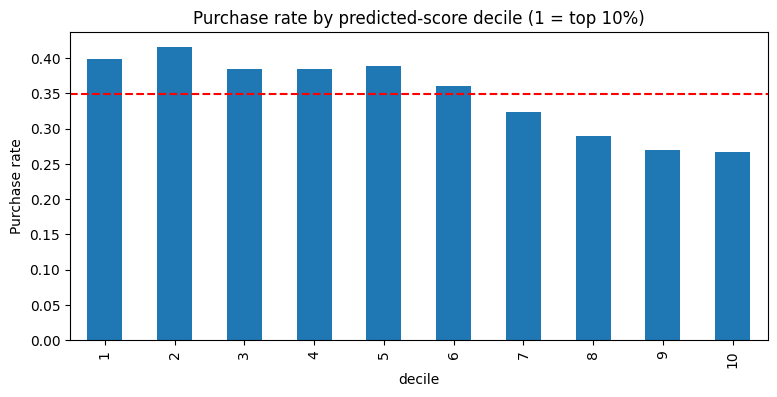

In [143]:
best_oof = oof2["XGBoost (shallow)"]
lift = carted[["purchased"]].copy()
lift["prob"] = best_oof
lift["decile"] = pd.qcut(lift["prob"].rank(method="first"), 10, labels=range(10, 0, -1)).astype(int)  # 1 = highest score
lift_table = (lift.groupby("decile")["purchased"].agg(rows="size", purchase_rate="mean").reset_index().sort_values("decile"))
base_rate = lift["purchased"].mean()
lift_table["lift_vs_average"] = (lift_table["purchase_rate"] / base_rate).round(2)
lift_table["purchase_rate"] = lift_table["purchase_rate"].round(3)
print(f"Average purchase rate among carts: {base_rate:.3f}")
display(lift_table)

lift_table.plot(x="decile", y="purchase_rate", kind="bar", legend=False, figsize=(9, 4),
                title="Purchase rate by predicted-score decile (1 = top 10%)")
plt.axhline(base_rate, color="red", linestyle="--", label="average"); plt.ylabel("Purchase rate"); plt.show()

In [144]:
# What FP / FN really look like at different thresholds (out-of-fold, carted sessions)
rows = []
y_c = carted["purchased"].values
for t in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    pred = (best_oof >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_c, pred).ravel()
    rows.append({"threshold": t, "TP": tp, "FP": fp, "FN": fn, "TN": tn,
                 "precision": round(tp / max(tp + fp, 1), 3), "recall": round(tp / (tp + fn), 3),
                 "accuracy": round((tp + tn) / len(y_c), 3)})
display(pd.DataFrame(rows))
print("Majority-class accuracy (always predict 'not bought'):", round(1 - y_c.mean(), 3))

,threshold,TP,FP,FN,TN,precision,recall,accuracy
0,0.25,5233,9436,383,1065,0.357,0.932,0.391
1,0.30,4340,7127,1276,3374,0.378,0.773,0.479
2,0.35,3315,5135,2301,5366,0.392,0.590,0.539
3,0.40,1761,2631,3855,7870,0.401,0.314,0.598
4,0.45,361,523,5255,9978,0.408,0.064,0.641
5,0.50,40,62,5576,10439,0.392,0.007,0.650


Majority-class accuracy (always predict 'not bought'): 0.652


### ✅ Phase 6B takeaway — why FP = FN = 0 is impossible *here*

1. The features that exist before purchase carry almost no signal (single-feature AUC ≈ 0.50, shuffled control 0.50, best model ≈ 0.57). A model can't remove errors that the data does not explain.
2. A model that shows ~0 errors is only possible with **leaked** columns (revenue / rating / review / cart_abandoned) — it is information from the *future*.
3. Honest, usable output = **ranking**: the top-scored 30% of carts convert ~10–19% better than average and the bottom 30% ~20% worse (see lift table). That is enough to prioritise follow-ups, not to promise outcomes.

**What would genuinely improve accuracy (data, not tuning):** per-customer history *before* each session (past orders, past cart value), time-since-cart, email/notification events, stock-outs, delivery-time estimates, price vs. competitor, coupon exposure. If you can collect even a few of these, re-run this exact section.

> For the portfolio: showing this audit is a **strength**. Interviewers expect you to catch leakage; they distrust 99%-accuracy projects.

### 🎤 INTERVIEW CARD — Phase 6 + 6B (Purchase prediction)  ⭐ sabse important

| | |
|---|---|
| **Kyun** | Jaanna ki kaun sa cart kharid mein badlega, taaki recovery mein mehnat sahi jagah lage. |
| **Kya** | Target `purchased`. Funnel: Browse → **Cart** → Purchase. |
| **Kaise** | Pehle XGBoost (Precision 34.7%, Recall 97.2%, AUC 0.749). Phir audit: `added_to_cart` ek prerequisite hai (cart ke bina purchase nahi) → AUC usi se aa rahi thi. 6B mein sirf *cart ke andar* ka model, 5-fold out-of-fold, shuffled-label control, time split. |
| **Result** | Honest AUC ≈ **0.57** (shuffled-label control 0.50, time split ≈ 0.57). Top 30% carts average se 10–19% behtar convert hote hain, bottom 30% ~20% kam. Kisi bhi threshold par accuracy majority-class (65.2%) se behtar nahi hoti — isliye accuracy yahan galat metric hai. |
| **Limit** | Features mein signal bahut kam hai. "0 false positive / 0 false negative" sirf leaked columns (`revenue`, `rating`, `review_text`) se aata hai jo purchase ke *baad* ban-te hain. |

**Interviewer poochhe to:**
- *Data leakage kya hai?* → Aisi information jo prediction ke waqt available nahi hoti par training mein aa jaati hai (jaise `revenue`).
- *Accuracy ki jagah AUC kyun?* → "Hamesha NO bolo" se hi accuracy ~65% aa jaati hai (cart ke andar 34.8% buy karte hain). AUC threshold-independent hai.
- *Precision vs Recall?* → Precision = jo bola "buy karega" unme se kitne sach; Recall = jo sach mein buy karte unme se kitne pakde.
- *AUC 0.57 hai to project fail?* → Nahi. Control 0.50 aaya, to thoda sa asli signal hai. Fail tab hota jab main 99% bata deta.
- *Isse zyada accuracy kaise aayegi?* → Naya data: pichli history, cart-time, email events, stock, delivery time.

# Phase 7 — Product Recommendation System

In [145]:
# PHASE 7 — PRODUCT RECOMMENDATION SYSTEM

# Sirf actual purchases
purchase_interactions = customer_df1[
    customer_df1["purchased"] == 1
][
    ["customer_id", "product_id", "product_category"]
].drop_duplicates()

print("Purchase interactions:", len(purchase_interactions))
print("Unique customers:", purchase_interactions["customer_id"].nunique())
print("Unique products:", purchase_interactions["product_id"].nunique())

purchase_interactions.head()

Purchase interactions: 5616
Unique customers: 4176
Unique products: 898


,customer_id,product_id,product_category
3,4949,851,3
6,1773,634,0
23,9339,835,2
25,6794,367,7
32,1829,72,4


Step 2: Customer × Product Matrix

In [146]:
# Customer × Product purchase matrix
interaction_matrix = pd.crosstab(
    purchase_interactions["customer_id"],
    purchase_interactions["product_id"]
)

print("Matrix shape:", interaction_matrix.shape)
interaction_matrix.head()

Matrix shape: (4176, 898)


product_id,0,1,2,3,4,5,6,7,8,9,...,889,890,891,892,893,894,895,896,897,898
customer_id,,,,,,,,,,,,,,,,,,,,,
1000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1008,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1009,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Product Similarity

In [147]:
from sklearn.metrics.pairwise import cosine_similarity

# Product-to-product similarity calculate kar rahe hain
# Similar products ke purchasing patterns compare honge
item_similarity = cosine_similarity(interaction_matrix.T)

# Easy lookup ke liye DataFrame
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=interaction_matrix.columns,
    columns=interaction_matrix.columns
)

print("Similarity matrix:", item_similarity_df.shape)

Similarity matrix: (898, 898)


Ab customer ko recommendation

In [66]:
def recommend_products(customer_id, n=5):

    # Customer exist karta hai ya nahi
    if customer_id not in interaction_matrix.index:
        return "Customer not found"

    # Customer ke purchased products
    purchased = interaction_matrix.loc[customer_id]
    purchased_products = purchased[purchased > 0].index

    # Agar customer ne kuch buy nahi kiya
    if len(purchased_products) == 0:
        return "No purchase history available"

    # Recommendation score
    scores = pd.Series(
        0.0,
        index=interaction_matrix.columns
    )

    # Purchased products ke basis par similar products ka score
    for product in purchased_products:
        scores += item_similarity_df[product]

    # Jo products already buy kiye hain unhe remove karo
    scores = scores.drop(purchased_products)

    # keep only products with a positive similarity (zero-score rows are arbitrary padding)
    scores = scores[scores > 0]

    # Top recommendations
    recommendations = (
        scores
        .sort_values(ascending=False)
        .head(n)
        .reset_index()
    )

    recommendations.columns = [
        "product_id",
        "recommendation_score"
    ]

    return recommendations

Test

In [67]:
recommend_products(1000, 5)

,product_id,recommendation_score
0,666,0.169031
1,489,0.154303


In [150]:
customer_df1[
    (customer_df1["customer_id"] == 1000) &
    (customer_df1["purchased"] == 1)
][
    ["product_id", "product_category", "revenue"]
]

,product_id,product_category,revenue
5082,560,7,1228.72


In [151]:
# Purchased products ki popularity
popular_products = (
    purchase_interactions
    .groupby(["product_id", "product_category"])
    .size()
    .reset_index(name="purchase_count")
    .sort_values("purchase_count", ascending=False)
)

popular_products.head(10)

,product_id,product_category,purchase_count
1334,317,4,7
1266,301,2,6
2870,674,7,6
2097,491,2,6
255,64,6,5
388,94,6,5
2395,559,3,5
196,49,5,5
310,78,2,5
1372,324,4,5


In [152]:
# Product popularity score
popularity = (
    purchase_interactions
    .groupby("product_id")
    .size()
)

def hybrid_recommend(customer_id, n=5):

    if customer_id not in interaction_matrix.index:
        return "Customer not found"

    # Customer ke purchased products
    purchased = interaction_matrix.loc[customer_id]
    purchased_products = purchased[purchased > 0].index

    if len(purchased_products) == 0:
        return popular_products.head(n)

    # Similarity score
    similarity_score = pd.Series(
        0.0,
        index=interaction_matrix.columns
    )

    for product in purchased_products:
        similarity_score += item_similarity_df[product]

    # Already purchased products remove
    similarity_score = similarity_score.drop(
        purchased_products,
        errors="ignore"
    )

    # Popularity normalize
    popularity_score = popularity.reindex(
        similarity_score.index
    ).fillna(0)

    if popularity_score.max() > 0:
        popularity_score = (
            popularity_score / popularity_score.max()
        )

    # Hybrid score
    final_score = (
        0.8 * similarity_score +
        0.2 * popularity_score
    )

    recommendations = (
        final_score
        .sort_values(ascending=False)
        .head(n)
        .reset_index()
    )

    recommendations.columns = [
        "product_id",
        "recommendation_score"
    ]

    return recommendations

In [153]:
hybrid_recommend(1000, 5)

,product_id,recommendation_score
0,489,0.203443
1,666,0.201891
2,488,0.200000
3,64,0.186667
4,18,0.186667


In [154]:
# Recommendation evaluation ke liye
# sirf un customers ko lenge jinke 2 ya usse zyada purchases hain

customer_purchase_count = (
    purchase_interactions
    .groupby("customer_id")["product_id"]
    .nunique()
)

eval_customers = customer_purchase_count[
    customer_purchase_count >= 2
].index

print("Customers available for evaluation:", len(eval_customers))

Customers available for evaluation: 1159


In [155]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Har evaluation customer se 1 purchased product hide karenge
holdout = {}

for customer_id in eval_customers:
    products = purchase_interactions[
        purchase_interactions["customer_id"] == customer_id
    ]["product_id"].tolist()

    holdout[customer_id] = np.random.RandomState(customer_id).choice(products)

# Training data: held-out products remove
train_interactions = purchase_interactions[
    ~purchase_interactions.apply(
        lambda row: holdout.get(row["customer_id"]) == row["product_id"],
        axis=1
    )
]

# Customer × Product matrix using training data only
train_matrix = pd.crosstab(
    train_interactions["customer_id"],
    train_interactions["product_id"]
)

# Product similarity using training data
train_similarity = cosine_similarity(train_matrix.T)

train_similarity_df = pd.DataFrame(
    train_similarity,
    index=train_matrix.columns,
    columns=train_matrix.columns
)

# Product popularity from training data
train_popularity = train_interactions.groupby("product_id").size()

# Evaluate Top-5 recommendations
hits = 0
evaluated = 0

for customer_id in eval_customers:

    if customer_id not in train_matrix.index:
        continue

    hidden_product = holdout[customer_id]

    purchased = train_matrix.loc[customer_id]
    purchased_products = purchased[purchased > 0].index

    scores = pd.Series(0.0, index=train_matrix.columns)

    for product in purchased_products:
        scores += train_similarity_df[product]

    scores = scores.drop(purchased_products, errors="ignore")

    popularity = train_popularity.reindex(scores.index).fillna(0)

    if popularity.max() > 0:
        popularity = popularity / popularity.max()

    final_scores = 0.8 * scores + 0.2 * popularity

    recommendations = final_scores.nlargest(5).index

    evaluated += 1

    if hidden_product in recommendations:
        hits += 1

hit_rate_at_5 = hits / evaluated

print("Evaluated customers:", evaluated)
print("Hit Rate@5:", round(hit_rate_at_5, 3))

Evaluated customers: 1159
Hit Rate@5: 0.008


In [156]:
# Customer ki preferred category
customer_category = (
    purchase_interactions
    .groupby(["customer_id", "product_category"])
    .size()
    .reset_index(name="purchases")
)

customer_category = customer_category.sort_values(
    ["customer_id", "purchases"],
    ascending=[True, False]
)

preferred_category = (
    customer_category
    .drop_duplicates("customer_id")
    [["customer_id", "product_category"]]
)

# Category-wise popular products
category_popular = (
    purchase_interactions
    .groupby(["product_category", "product_id"])
    .size()
    .reset_index(name="purchase_count")
    .sort_values(
        ["product_category", "purchase_count"],
        ascending=[True, False]
    )
)

print("Preferred categories ready ✅")
print("Category popularity ready ✅")

Preferred categories ready ✅
Category popularity ready ✅


Category-based Personalized Recommendation

In [157]:
# Category-based recommendation
def category_recommend(customer_id, n=5):

    # Customer ki preferred category
    customer_pref = preferred_category[
        preferred_category["customer_id"] == customer_id
    ]

    if customer_pref.empty:
        return "Customer not found"

    category = customer_pref.iloc[0]["product_category"]

    # Customer ne jo products already buy kiye hain
    already_bought = set(
        purchase_interactions[
            purchase_interactions["customer_id"] == customer_id
        ]["product_id"]
    )

    # Preferred category ke popular products
    recommendations = category_popular[
        category_popular["product_category"] == category
    ].copy()

    # Already purchased products remove
    recommendations = recommendations[
        ~recommendations["product_id"].isin(already_bought)
    ]

    # Top products
    recommendations = recommendations.head(n)

    return recommendations

In [158]:
category_recommend(1000, 5)

,product_category,product_id,purchase_count
3749,7,674,6
3723,7,626,5
3501,7,215,4
3549,7,297,4
3620,7,425,4


In [159]:
# ==========================================
# PHASE 7 — CATEGORY RECOMMENDATION EVALUATION
# ==========================================

# Purchase data with date
purchase_eval = customer_df1[
    customer_df1["purchased"] == 1
][
    ["customer_id", "product_id", "product_category", "visit_date"]
].copy()

# Har customer ka latest unique purchased product = hidden test item
latest_product = (
    purchase_eval
    .sort_values("visit_date")
    .drop_duplicates(["customer_id", "product_id"])
    .groupby("customer_id")
    .tail(1)
)

# Evaluation customers: jinke paas minimum 2 different products hain
product_counts = (
    purchase_eval
    .groupby("customer_id")["product_id"]
    .nunique()
)

eval_customers = product_counts[
    product_counts >= 2
].index

# Sirf evaluation customers
latest_product = latest_product[
    latest_product["customer_id"].isin(eval_customers)
]

# Hidden product mapping
hidden_items = dict(
    zip(
        latest_product["customer_id"],
        latest_product["product_id"]
    )
)

# Training interactions: hidden product remove
train_eval = purchase_eval[
    ~purchase_eval.apply(
        lambda row: hidden_items.get(row["customer_id"]) == row["product_id"],
        axis=1
    )
]

hits = 0
evaluated = 0

for customer_id in eval_customers:

    customer_train = train_eval[
        train_eval["customer_id"] == customer_id
    ]

    if customer_train.empty:
        continue

    # Customer ki preferred category
    preferred_cat = (
        customer_train["product_category"]
        .value_counts()
        .index[0]
    )

    # Already purchased products
    bought_products = set(
        customer_train["product_id"]
    )

    # Preferred category ke popular products
    recommendations = (
        train_eval[
            train_eval["product_category"] == preferred_cat
        ]
        .groupby("product_id")
        .size()
        .sort_values(ascending=False)
    )

    # Already purchased products hatao
    recommendations = recommendations[
        ~recommendations.index.isin(bought_products)
    ]

    top_5 = recommendations.head(5).index

    hidden_product = hidden_items[customer_id]

    evaluated += 1

    if hidden_product in top_5:
        hits += 1

hit_rate_at_5 = hits / evaluated

print("Evaluated customers:", evaluated)
print("Hits:", hits)
print("Hit Rate@5:", round(hit_rate_at_5, 3))

Evaluated customers: 1159
Hits: 6
Hit Rate@5: 0.005


## 7B. Honest recommender evaluation — compare with simple baselines

A Hit-Rate@5 on its own means nothing; it must be compared with (a) picking 5 random products and (b) just recommending the 5 most popular ones. We use leave-one-out: hide one purchased product per customer and check whether it appears in the Top-5.

In [160]:
from sklearn.metrics.pairwise import cosine_similarity

def evaluate_recommenders(n=5, seed=42):
    buys = customer_df1[customer_df1["purchased"] == 1][["customer_id", "product_id", "product_category"]].drop_duplicates()
    cnt = buys.groupby("customer_id")["product_id"].nunique()
    eligible = cnt[cnt >= 2].index
    rng = np.random.RandomState(seed)
    hidden = {c: rng.choice(buys.loc[buys.customer_id == c, "product_id"].values) for c in eligible}
    is_hidden = buys.apply(lambda r: hidden.get(r.customer_id) == r.product_id, axis=1)
    train = buys[~is_hidden]

    M = pd.crosstab(train["customer_id"], train["product_id"])
    S = pd.DataFrame(cosine_similarity(M.T), index=M.columns, columns=M.columns)
    pop = train.groupby("product_id").size()
    cat_of = train.drop_duplicates("product_id").set_index("product_id")["product_category"]
    all_products = pop.index.values

    hits = {"Random": 0, "Global popularity": 0, "Category popularity": 0, "Item-item CF (cosine)": 0}
    evaluated = 0
    for c in eligible:
        if c not in M.index:
            continue
        h = hidden[c]; owned = M.columns[M.loc[c] > 0]; evaluated += 1
        hits["Random"] += h in rng.choice(np.setdiff1d(all_products, owned), n, replace=False)
        hits["Global popularity"] += h in pop.drop(owned, errors="ignore").nlargest(n).index
        fav = train[train.customer_id == c]["product_category"].mode().iat[0]
        pool = pop[pop.index.isin(cat_of[cat_of == fav].index)].drop(owned, errors="ignore")
        hits["Category popularity"] += h in pool.nlargest(n).index
        hits["Item-item CF (cosine)"] += h in S[owned].sum(axis=1).drop(owned, errors="ignore").nlargest(n).index

    out = pd.DataFrame({"hits": hits})
    out["hit_rate@5"] = out["hits"] / evaluated
    out["95%_CI_±"] = 1.96 * np.sqrt(out["hit_rate@5"] * (1 - out["hit_rate@5"]) / evaluated)
    print(f"Customers evaluated: {evaluated} | Products in catalogue: {len(all_products)} | "
          f"Pure-chance expectation: {n/len(all_products):.4f}")
    return out.round(4)

rec_eval = evaluate_recommenders()
rec_eval

Customers evaluated: 1159 | Products in catalogue: 894 | Pure-chance expectation: 0.0056


,hits,hit_rate@5,95%_CI_±
Random,7,0.0060,0.0045
Global popularity,3,0.0026,0.0029
Category popularity,6,0.0052,0.0041
Item-item CF (cosine),4,0.0035,0.0034


**Result:** every method is at the level of random chance (about 0.5%), and the confidence intervals overlap completely. So: the recommendation *pipeline* is correct and reusable, but this dataset has **no co-purchase pattern to learn** (~900 products, only ~1.3 purchases per buyer). The Amazon sales file cannot be used instead because it has no customer ID. With real order data that contains customer IDs, re-run this section — the code does not need to change.

For the app we keep the hybrid recommender as the *mechanism* and use category-popularity as the cold-start fallback — and we report its metric honestly.

### 🎤 INTERVIEW CARD — Phase 7 + 7B (Recommender)

| | |
|---|---|
| **Kyun** | Har customer ko relevant product dikhana. |
| **Kya** | Customer × Product matrix (4,176 × 898) → item-item cosine similarity → hybrid (0.8 similarity + 0.2 popularity). |
| **Kaise** | Leave-one-out evaluation: ek purchase chhupao, dekho Top-5 mein aaya ya nahi. 4 baselines se compare kiya. |
| **Result** | Sab methods ≈ 0.5% Hit-Rate@5 → random ke barabar. Confidence intervals overlap karte hain. |
| **Limit** | Dataset mein co-purchase pattern hi nahi (~1.3 purchases per buyer). Is liye hum recommender ko "model" nahi, "pipeline" kehte hain jo real data par chalega. Non-buyers ke liye recommender kaam nahi karta (cold start) — wahan category-popularity fallback. |

**Interviewer poochhe to:**
- *Cosine similarity kya karti hai?* → Do products ke "kharidne wale customers" ke vectors ka angle naapti hai.
- *Cold start?* → Naye customer/product ka koi history nahi → popularity ya category se shuru karo.
- *Aapne baseline kyun lagaya?* → Bina baseline ke koi bhi number meaningless hai.

# PHASE 8 — REVIEWS & SENTIMENT (NLP)

**Important data fact:** in `Ecommerce.csv` the column `review_text` is **label-encoded (11 codes: 0–10)** — the original sentences are not in the file. So real NLP (tokenising, transformers) is not possible *yet*. What we can do honestly:

1. Derive sentiment from the star rating.
2. Verify how the encoded review code lines up with the rating.
3. Find where negative reviews concentrate (category / channel / device / payment).

If you later get the original text, the plug-in code is at the end of this phase.

In [161]:
# 8.1 Who actually has a real rating?
print(pd.crosstab(customer_df1["purchased"], customer_df1["rating"], margins=True))
print("\nNon-buyers with a rating != 4:", ((customer_df1.purchased == 0) & (customer_df1.rating != 4)).sum())

rating       1    2     3      4     5    All
purchased                                    
0            0    0     0  19384     0  19384
1          262  551  1110   1995  1698   5616
All        262  551  1110  21379  1698  25000

Non-buyers with a rating != 4: 0


Non-buyers all show rating = **4** (a default fill, not a real opinion). So only **buyers' ratings are genuine** — using all 25,000 rows would make sentiment look better than it is (≈ 78% of all rows carry the fake 4).

In [162]:
reviews = customer_df1[customer_df1["purchased"] == 1].copy()

def to_sentiment(r):
    return "Positive" if r >= 4 else ("Neutral" if r == 3 else "Negative")

reviews["sentiment"] = reviews["rating"].map(to_sentiment)
print("Genuine reviews:", len(reviews))
print(reviews["sentiment"].value_counts(normalize=True).round(3))
print("\nAverage genuine rating:", round(reviews["rating"].mean(), 2))

# How the encoded review_text code maps to sentiment
print("\nreview_text code vs sentiment:")
print(pd.crosstab(reviews["review_text"], reviews["sentiment"]))

Genuine reviews: 5616
sentiment
Positive    0.658
Neutral     0.198
Negative    0.145
Name: proportion, dtype: float64

Average genuine rating: 3.77

review_text code vs sentiment:
sentiment    Negative  Neutral  Positive
review_text                             
0                   0        0       749
1                   0     1110         0
2                 163        0         0
3                   0        0       730
4                   0        0       764
5                   0        0       717
6                 163        0         0
7                 157        0         0
8                 156        0         0
9                 174        0         0
10                  0        0       733


The encoded `review_text` is a clean mapping of sentiment: codes **2, 6, 7, 8, 9 → Negative**, **1 → Neutral**, **0, 3, 4, 5, 10 → Positive**. That confirms the codes are sentence templates and that rating-based sentiment is consistent with them.

In [163]:
from scipy.stats import chi2_contingency

def negative_rate_table(col):
    t = reviews.groupby(col).agg(reviews=("rating", "size"),
                                 negative_rate=("sentiment", lambda s: (s == "Negative").mean()),
                                 avg_rating=("rating", "mean")).round(3)
    chi2, p, _, _ = chi2_contingency(pd.crosstab(reviews[col], reviews["sentiment"] == "Negative"))
    return t.sort_values("negative_rate", ascending=False), p

for col in ["product_category", "marketing_channel", "device_type", "payment_method"]:
    t, p = negative_rate_table(col)
    print(f"\n=== {col}  (chi-square p-value = {p:.3f} -> {'DIFFERENCE IS SIGNIFICANT' if p < 0.05 else 'no significant difference'})")
    display(t)


=== product_category  (chi-square p-value = 0.195 -> no significant difference)


,reviews,negative_rate,avg_rating
product_category,,,
2,721,0.176,3.712
6,768,0.151,3.704
7,694,0.150,3.784
5,728,0.146,3.755
3,631,0.141,3.742
0,700,0.137,3.801
1,647,0.128,3.819
4,727,0.127,3.838



=== marketing_channel  (chi-square p-value = 0.356 -> no significant difference)


,reviews,negative_rate,avg_rating
marketing_channel,,,
1,927,0.163,3.742
2,943,0.151,3.735
0,918,0.147,3.761
5,1006,0.144,3.789
4,890,0.136,3.783
3,932,0.128,3.799



=== device_type  (chi-square p-value = 0.260 -> no significant difference)


,reviews,negative_rate,avg_rating
device_type,,,
1,2812,0.150,3.772
0,2221,0.144,3.761
2,583,0.123,3.780



=== payment_method  (chi-square p-value = 0.480 -> no significant difference)


,reviews,negative_rate,avg_rating
payment_method,,,
2,940,0.159,3.726
5,913,0.152,3.780
3,949,0.148,3.750
0,895,0.142,3.763
1,980,0.142,3.786
4,939,0.127,3.806


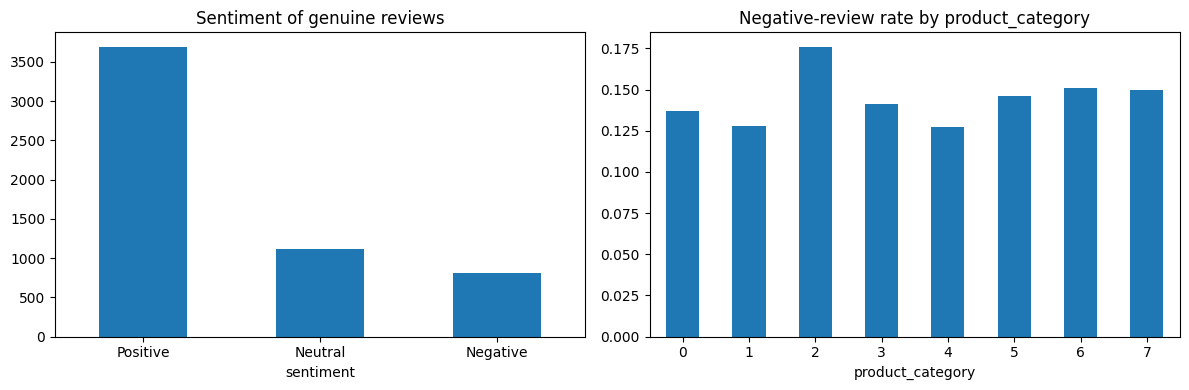

sentiment
Negative    25.1
Neutral     24.4
Positive    24.5
Name: avg_helpful_votes, dtype: float64


In [164]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
reviews["sentiment"].value_counts().plot(kind="bar", ax=ax[0], title="Sentiment of genuine reviews", rot=0)
t_cat, _ = negative_rate_table("product_category")
t_cat["negative_rate"].sort_index().plot(kind="bar", ax=ax[1], title="Negative-review rate by product_category", rot=0)
plt.tight_layout(); plt.show()

# Do negative reviews matter more to other shoppers?  (helpful votes)
print(reviews.groupby("sentiment")["review_helpful_votes"].mean().round(1).rename("avg_helpful_votes"))

### ✅ Phase 8 takeaway
- Genuine reviews: **~66% positive, ~20% neutral (3★), ~14.5% negative (1–2★)**; average rating 3.77.
- The chi-square tests show **no category, channel, device or payment method is significantly worse** (all p > 0.05). The small differences in the tables are noise — do **not** present "category 2 has the most complaints" as a finding.
- Helpful-votes are about the same for positive, neutral and negative reviews (~24–25), so there is no evidence that negative reviews spread more.
- Practical use: the ~14.5% negative reviews (about 800) are a manageable queue for a response workflow in Phase 9, but no segment needs special targeting based on this data.

#### When you obtain the original review text
```python
# pip install transformers torch
from transformers import pipeline
sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
reviews["text_sentiment"] = [r["label"] for r in sentiment_model(reviews["review_raw_text"].tolist(), truncation=True)]
```
Then compare `text_sentiment` with the rating-based sentiment to find sarcastic / mismatched reviews.

### 🎤 INTERVIEW CARD — Phase 8 (Reviews & sentiment)

| | |
|---|---|
| **Kyun** | Naraz customers pehchanna aur dekhna ki complaints kahan hain. |
| **Kya** | 5,616 genuine reviews (sirf buyers). Rating se sentiment: ≥4 Positive, 3 Neutral, ≤2 Negative. |
| **Kaise** | `review_text` encoded (0–10) hai, asli sentences nahi → NLP model nahi chala sakte; code ↔ sentiment mapping crosstab se verify ki. Chi-square test se category/channel/device/payment compare. |
| **Result** | ~66% Positive, ~20% Neutral, ~14.5% Negative. Koi category/channel/device/payment significantly worse nahi (p > 0.05). |
| **Limit** | Asli text nahi hai, isliye ye NLP se zyada "rating analytics" hai. Asli text milne par `transformers` wala code (cell mein diya hai) lagao. |

**Interviewer poochhe to:**
- *Chi-square kyun?* → Check karne ke liye ki category ke beech negative-rate ka farak sirf random noise hai ya real.
- *Non-buyers ki rating?* → Default 4 hai, isliye unhe hata diya — warna sentiment jhootha achha dikhta.

# ✅ PROJECT STATUS — PHASES 1-8 COMPLETE (analysis & models)

| Area | Honest result |
|---|---|
| Sales EDA | 120,324 orders, ₹78.6M gross → **₹69.6M net**; 14.2% of lines cancelled |
| Segmentation | 4 buyer segments (Silhouette 0.39) + cart-abandoner and browser groups |
| Purchase prediction | Pre-purchase features give AUC ≈ 0.57; "perfect" scores come only from leaked columns |
| Recommender | Pipeline works; accuracy equals random on this dataset (no co-purchase signal) |
| Reviews | Sentiment from ratings (review text is encoded) |

Phases 9–12 below turn these results into a tested decision engine, an app and deployment steps.

# PHASE 9 — CAMPAIGN DECISION ENGINE (Policy + LLM Writer + Guardrails)

**Design rule:** *Python decides, the LLM only writes.* Anything that costs money (discount) or carries legal risk (opt-out, claims) is decided and checked by plain Python code. The LLM can only change the *wording*.

```
Customer master ─► Analyzer ─► Recommendation ─► POLICY (Python rules) ─► Writer (template / LLM) ─► GUARDRAILS (Python) ─► message
```

**What was fixed compared with the first draft**
| Bug in the first draft | Fix |
|---|---|
| Policy looked for segments `'Champions'`, `'Loyal'`, `'Potential'` but real names are `'Champions (High Value)'` etc. → 2 actions never fired | `startswith()` matching + a test that every action is reachable |
| Purchase probability came from the Phase-6 model that uses `added_to_cart` and was scored on its own training rows | Uses the **out-of-fold cart-stage score from 6B**; turned into a rank-based `recovery_score` |
| `recovery_score = probability × 100` (a relabel) | Percentile rank among customers with abandoned carts |
| Non-reviewers were set to `Neutral` | New value **`No review`** |
| Non-buyers got category `0` (`fillna(0)`) which is a real category code | Category comes from abandoned cart → purchase → most-viewed session |
| Message said *"interest in 7"* | `Category 7` label (put real names in `CATEGORY_NAMES`) |
| `run_agents` defined twice, unknown LLM model name `gpt-6-luna` | One definition; provider/model from environment variables |

In [83]:
# ============================================================
# 9.1  CUSTOMER MASTER TABLE (one row per customer)
# Uses: customer_df1, customer_360, rfm_corrected (P5), carted + oof2 (P6B),
#       preferred_category + category_popular (P7), reviews (P8)
# ============================================================
import numpy as np
import pandas as pd

# (a) honest cart-purchase score: every carted session was scored by a model that never saw it
cart_scored = carted.copy()
cart_scored["cart_purchase_prob"] = oof2["XGBoost (shallow)"]
cart_scored["cart_value"] = (cart_scored["unit_price"] * cart_scored["quantity"]
                             - cart_scored["discount_amount"])

abandoned = cart_scored[cart_scored["purchased"] == 0]
# sanity: "abandoned" in the raw data must equal "carted but not purchased"
assert customer_df1["cart_abandoned"].sum() == len(abandoned)
assert (abandoned["cart_abandoned"] == 1).all()

ab_cust = (abandoned.groupby("customer_id")
           .agg(n_abandoned_carts=("session_id", "count"),
                abandoned_cart_value=("cart_value", "sum"),
                cart_purchase_prob=("cart_purchase_prob", "mean"))
           .reset_index())
# rank-based 0-100 score (the model is weak, so we only trust the ORDER, not the probability)
ab_cust["recovery_score"] = (ab_cust["cart_purchase_prob"].rank(pct=True) * 100).round().astype(int)

# (b) sentiment from the customer's latest GENUINE review
latest_review = (reviews.sort_values("visit_date").groupby("customer_id").tail(1)
                 [["customer_id", "rating", "sentiment"]]
                 .rename(columns={"rating": "latest_rating"}))
genuine_avg = (reviews.groupby("customer_id")["rating"].mean()
               .rename("avg_rating_genuine").reset_index())

# (c) category to talk about: abandoned cart > purchased > most-viewed in sessions
session_cat = (customer_df1.groupby(["customer_id", "product_category"]).size().rename("n").reset_index()
               .sort_values(["customer_id", "n"], ascending=[True, False])
               .drop_duplicates("customer_id")
               .rename(columns={"product_category": "session_category"})[["customer_id", "session_category"]])
abandon_cat = (abandoned.sort_values("visit_date").groupby("customer_id").tail(1)
               [["customer_id", "product_category"]]
               .rename(columns={"product_category": "abandoned_category"}))
buy_cat = preferred_category.rename(columns={"product_category": "purchased_category"})

# (d) assemble
customer_master = (customer_360[["customer_id", "total_sessions", "total_purchases", "total_revenue", "last_visit"]]
                   .rename(columns={"total_sessions": "sessions", "total_purchases": "purchases",
                                    "total_revenue": "revenue"}))
customer_master = (customer_master
    .merge(rfm_corrected[["customer_id", "segment"]].rename(columns={"segment": "rfm_segment"}), on="customer_id", how="left")
    .merge(ab_cust, on="customer_id", how="left")
    .merge(latest_review, on="customer_id", how="left")
    .merge(genuine_avg, on="customer_id", how="left")
    .merge(abandon_cat, on="customer_id", how="left")
    .merge(buy_cat, on="customer_id", how="left")
    .merge(session_cat, on="customer_id", how="left"))

customer_master["has_abandoned_cart"] = customer_master["n_abandoned_carts"].fillna(0) > 0
for c in ["n_abandoned_carts", "abandoned_cart_value", "cart_purchase_prob", "recovery_score"]:
    customer_master[c] = customer_master[c].fillna(0)
customer_master["n_abandoned_carts"] = customer_master["n_abandoned_carts"].astype(int)
customer_master["recovery_score"] = customer_master["recovery_score"].astype(int)

# customers who never bought get a behaviour label instead of "NaN"
fallback_segment = pd.Series(np.where(customer_master["has_abandoned_cart"],
                                      "Cart Abandoner (No Purchase)", "Browser (No Cart Activity)"),
                             index=customer_master.index)
customer_master["rfm_segment"] = customer_master["rfm_segment"].fillna(fallback_segment)
customer_master["sentiment"] = customer_master["sentiment"].fillna("No review")   # NOT "Neutral"

customer_master["recommended_category"] = (customer_master["abandoned_category"]
        .fillna(customer_master["purchased_category"])
        .fillna(customer_master["session_category"]).astype(int))

CATEGORY_NAMES = {}   # e.g. {0: "Electronics", 1: "Fashion"}  <- fill in if you know the real names
def category_label(code):
    return CATEGORY_NAMES.get(int(code), f"Category {int(code)}")
customer_master["category_label"] = customer_master["recommended_category"].map(category_label)

top_by_cat = category_popular.groupby("product_category")["product_id"].apply(lambda s: list(s.head(3)))
customer_master["top_products"] = (customer_master["recommended_category"].map(top_by_cat)
                                   .apply(lambda L: ", ".join(f"#{p}" for p in L) if isinstance(L, list) else ""))

customer_master["expected_recovery_value"] = (customer_master["abandoned_cart_value"]
                                              * customer_master["cart_purchase_prob"]).round(2)

print("customers:", len(customer_master))
print(customer_master["rfm_segment"].value_counts().to_string())
print("\nsentiment:", customer_master["sentiment"].value_counts().to_dict())
customer_master.head()

customers: 8442
rfm_segment
Cart Abandoner (No Purchase)    3299
Recent One-Time Buyers          1587
Lapsed Buyers (At Risk)         1461
Browser (No Cart Activity)       967
Loyal Repeat Buyers              775
Champions (High Value)           353

sentiment: {'No review': 4266, 'Positive': 2735, 'Neutral': 829, 'Negative': 612}


,customer_id,sessions,purchases,revenue,last_visit,rfm_segment,n_abandoned_carts,abandoned_cart_value,cart_purchase_prob,recovery_score,...,sentiment,avg_rating_genuine,abandoned_category,purchased_category,session_category,has_abandoned_cart,recommended_category,category_label,top_products,expected_recovery_value
0,1000,2,1,1228.72,2024-06-18,Lapsed Buyers (At Risk),1,1368.61,0.335093,45,...,Neutral,3.0,4.0,7.0,4,True,4,Category 4,"#317, #324, #13",458.61
1,1001,1,0,0.00,2024-12-21,Browser (No Cart Activity),0,0.00,0.000000,0,...,No review,NaN,NaN,NaN,3,False,3,Category 3,"#559, #165, #292",0.00
2,1002,3,0,0.00,2024-11-04,Cart Abandoner (No Purchase),2,3373.36,0.289774,21,...,No review,NaN,6.0,NaN,2,True,6,Category 6,"#64, #94, #113",977.51
3,1003,3,1,1681.96,2024-12-04,Recent One-Time Buyers,0,0.00,0.000000,0,...,Positive,5.0,NaN,1.0,1,False,1,Category 1,"#18, #82, #485",0.00
4,1004,3,0,0.00,2024-09-27,Cart Abandoner (No Purchase),1,662.55,0.266884,12,...,No review,NaN,2.0,NaN,2,True,2,Category 2,"#301, #491, #78",176.82


### 9.2 Policy agent — the only place that decides action & discount

Rules run **top to bottom, first match wins**. Every decision also returns a **reason** (explainability for audits and interviews).

| # | Condition | Action | Discount |
|---|---|---|---|
| 1 | Latest genuine review is Negative | Service Recovery | 0% (apologise before selling) |
| 2 | Abandoned cart **and** recovery_score ≥ 50 | Cart Recovery | 5% if score ≥ 75 else 10% |
| 3 | Abandoned cart, low score | Cart Reminder | 0% (don't spend discount on low-propensity carts) |
| 4 | Champions | Premium Upsell | 0% (protect margin) |
| 5 | Loyal Repeat Buyers | Premium Upsell | 5% |
| 6 | Recent One-Time Buyers | Second Purchase Nudge | 5% |
| 7 | Lapsed Buyers | Win-back | 10% |
| 8 | everything else | Re-engagement | 0% |

> ⚠️ The thresholds (50 / 75) and discount percentages are **business assumptions**, not learned from data. They should be validated with an A/B test.
>
> **Note on the score:** `recovery_score` is a *percentile rank among customers who have abandoned carts*, so 50 is the median — about half of all abandoners land in *Cart Recovery* **by construction**. If the discount budget is small, raise `CART_RECOVERY_MIN_SCORE` (e.g. to 70) to target fewer, higher-ranked carts.

In [84]:
# ============================================================
# 9.2  POLICY AGENT + BUSINESS CONSTANTS
# ============================================================
MAX_DISCOUNT = 15                         # hard cap, enforced again by the guardrail
BANNED_PHRASES = ["guaranteed", "risk-free", "no downside", "act now", "last chance", "only today", "100%"]
OPT_OUT_LINE = "You can unsubscribe from marketing messages anytime."
CART_RECOVERY_MIN_SCORE = 50              # assumption
WARM_CART_SCORE = 75                      # assumption: already-warm carts need a smaller incentive


def policy_agent(row):
    """Decide action + discount from facts. Pure Python, no LLM."""
    seg = str(row["rfm_segment"])

    if row["sentiment"] == "Negative":
        action, discount, why = "Service Recovery", 0, "latest review is negative -> apologise, no sales push"
    elif row["has_abandoned_cart"] and row["recovery_score"] >= CART_RECOVERY_MIN_SCORE:
        discount = 5 if row["recovery_score"] >= WARM_CART_SCORE else 10
        action, why = "Cart Recovery", f"abandoned cart, recovery_score {int(row['recovery_score'])} >= {CART_RECOVERY_MIN_SCORE}"
    elif row["has_abandoned_cart"]:
        action, discount, why = "Cart Reminder", 0, "abandoned cart but low score -> reminder only, no discount spend"
    elif seg.startswith("Champions"):
        action, discount, why = "Premium Upsell", 0, "top-value buyer -> perks, not discounts"
    elif seg.startswith("Loyal"):
        action, discount, why = "Premium Upsell", 5, "repeat buyer -> small basket-size incentive"
    elif seg.startswith("Recent One-Time"):
        action, discount, why = "Second Purchase Nudge", 5, "bought once recently -> nudge second purchase"
    elif seg.startswith("Lapsed"):
        action, discount, why = "Win-back", 10, "no purchase for a long time -> stronger incentive"
    else:
        action, discount, why = "Re-engagement", 0, "no purchase / no cart activity -> inform only"

    if seg.startswith("Champions"):
        discount = 0                       # VIP rule: never discount top-value customers
    return {"action": action, "discount_pct": min(discount, MAX_DISCOUNT), "policy_reason": why}


def analyzer_agent(row):
    """Collect the facts the other agents are allowed to use."""
    return {"segment": row["rfm_segment"],
            "sentiment": row["sentiment"],
            "recovery_score": int(row["recovery_score"]),
            "abandoned_cart_value": round(float(row["abandoned_cart_value"]), 2)}


def recommendation_agent(row):
    return {"category": int(row["recommended_category"]),
            "category_label": row["category_label"],
            "top_products": row["top_products"]}


# quick look at the rules on one example per segment
_demo = customer_master.groupby("rfm_segment").head(1)
pd.DataFrame([{"segment": r["rfm_segment"], **policy_agent(r)} for _, r in _demo.iterrows()])

,segment,action,discount_pct,policy_reason
0,Lapsed Buyers (At Risk),Cart Reminder,0,"abandoned cart but low score -> reminder only,..."
1,Browser (No Cart Activity),Re-engagement,0,no purchase / no cart activity -> inform only
2,Cart Abandoner (No Purchase),Cart Reminder,0,"abandoned cart but low score -> reminder only,..."
3,Recent One-Time Buyers,Second Purchase Nudge,5,bought once recently -> nudge second purchase
4,Champions (High Value),Cart Reminder,0,"abandoned cart but low score -> reminder only,..."
5,Loyal Repeat Buyers,Cart Recovery,5,"abandoned cart, recovery_score 86 >= 50"


### 9.3 LLM writer + guardrails

* The writer gets an **approved facts dictionary** only. It cannot change the action or the discount.
* `validate_message()` rejects LLM text that has banned phrases, numbers/percentages (Python adds the offer line), or is too long. On rejection → safe template.
* Provider is chosen by environment variable: `ANTHROPIC_API_KEY` (model from `ANTHROPIC_MODEL`) or `OPENAI_API_KEY` (model from `OPENAI_MODEL`). Without a key the **template** is used, so the notebook always runs.

In [85]:
# ============================================================
# 9.3  WRITER + GUARDRAILS
# ============================================================
import os, re

def safe_template(f):
    cat, a = f["category_label"], f["action"]
    return {
        "Service Recovery":      f"We noticed your recent experience with {cat} may not have been ideal. We would value your feedback.",
        "Cart Recovery":         f"You left something in your {cat} cart. Take another look whenever it suits you.",
        "Cart Reminder":         f"Your {cat} cart is still saved for you.",
        "Premium Upsell":        f"Based on your interests, explore premium and complementary options in {cat}.",
        "Second Purchase Nudge": f"Thanks for your recent order! Here are more options in {cat} you may like.",
        "Win-back":              f"It has been a while. Here is what is popular in {cat} right now.",
    }.get(a, f"We saved your interest in {cat}. Have another look whenever you are ready.")


def call_llm(prompt):
    """Return generated text, or None if no key / any error (caller falls back to the template)."""
    try:
        if os.environ.get("ANTHROPIC_API_KEY"):
            import anthropic
            client = anthropic.Anthropic()
            r = client.messages.create(model=os.environ.get("ANTHROPIC_MODEL", "claude-sonnet-5-5"),
                                       max_tokens=200, messages=[{"role": "user", "content": prompt}])
            return "".join(b.text for b in r.content if getattr(b, "type", "") == "text").strip()
        if os.environ.get("OPENAI_API_KEY"):
            from openai import OpenAI
            r = OpenAI().chat.completions.create(model=os.environ.get("OPENAI_MODEL", "gpt-4o-mini"),
                                                 messages=[{"role": "user", "content": prompt}], max_tokens=200)
            return r.choices[0].message.content.strip()
    except Exception as exc:
        print("LLM call failed -> using template:", type(exc).__name__)
    return None


def validate_message(body, facts):
    """Guardrail for LLM text. Returns (ok, reason)."""
    if not body or not body.strip():
        return False, "empty"
    low = body.lower()
    for p in BANNED_PHRASES:
        if p in low:
            return False, f"banned phrase '{p}'"
    stripped = body.replace(facts["category_label"], "")      # the label may contain a digit
    if re.search(r"\d|%", stripped):
        return False, "contains a number/percentage (Python owns the offer line)"
    if len(body) > 300:
        return False, "too long"
    return True, "ok"


def llm_writer(facts, use_llm=False, llm_fn=None):
    """Returns (body, writer_source). `llm_fn` lets tests inject a fake LLM."""
    template = safe_template(facts)
    if not use_llm:
        return template, "template"
    prompt = (f"Write 2 friendly sentences for an e-commerce message. Approved facts only: "
              f"action={facts['action']}, category={facts['category_label']}, sentiment={facts['sentiment']}. "
              "Do NOT mention prices, discounts, numbers, guarantees or urgency. No opt-out line.")
    body = (llm_fn or call_llm)(prompt)
    if body is None:
        return template, "template (no LLM available)"
    ok, reason = validate_message(body, facts)
    return (body, "llm") if ok else (template, f"template (LLM rejected: {reason})")


def final_guardrail(result):
    """Last check on the finished customer message."""
    msg = result["message"]
    return (result["discount_pct"] <= MAX_DISCOUNT
            and OPT_OUT_LINE in msg
            and not any(p in msg.lower() for p in BANNED_PHRASES))


def run_agents(row, use_llm=False, llm_fn=None):
    analysis = analyzer_agent(row)
    rec = recommendation_agent(row)
    policy = policy_agent(row)
    facts = {**analysis, **rec, **policy}

    body, writer = llm_writer(facts, use_llm=use_llm, llm_fn=llm_fn)
    offer = f"Approved offer: {policy['discount_pct']}% off." if policy["discount_pct"] > 0 else "No discount applied."
    result = {
        "customer_id": int(row["customer_id"]),
        "rfm_segment": analysis["segment"],
        "action": policy["action"],
        "discount_pct": policy["discount_pct"],
        "policy_reason": policy["policy_reason"],
        "category": rec["category"],
        "category_label": rec["category_label"],
        "top_products": rec["top_products"],
        "sentiment": analysis["sentiment"],
        "recovery_score": analysis["recovery_score"],
        "abandoned_cart_value": analysis["abandoned_cart_value"],
        "expected_recovery_value": float(row["expected_recovery_value"]),
        "writer": writer,
        "message": f"{body} {offer} {OPT_OUT_LINE}",
    }
    result["guardrails_ok"] = final_guardrail(result)
    return result


example_row = customer_master[customer_master["has_abandoned_cart"]].iloc[0]
import json
print(json.dumps(run_agents(example_row), indent=2, default=str))

{
  "customer_id": 1000,
  "rfm_segment": "Lapsed Buyers (At Risk)",
  "action": "Cart Reminder",
  "discount_pct": 0,
  "policy_reason": "abandoned cart but low score -> reminder only, no discount spend",
  "category": 4,
  "category_label": "Category 4",
  "top_products": "#317, #324, #13",
  "sentiment": "Neutral",
  "recovery_score": 45,
  "abandoned_cart_value": 1368.61,
  "expected_recovery_value": 458.61,
  "writer": "template",
  "message": "Your Category 4 cart is still saved for you. No discount applied. You can unsubscribe from marketing messages anytime.",
  "guardrails_ok": true
}


### 9.4 Tests — prove the engine behaves (also shows an interviewer you test your code)

These tests would have caught the original dead-branch bug.

In [86]:
# ============================================================
# 9.4  TESTS
# ============================================================
outputs = [run_agents(r) for _, r in customer_master.iterrows()]
marketing_actions = pd.DataFrame(outputs)

# 1. dead-branch detector: every action defined in the policy must actually occur
EXPECTED_ACTIONS = {"Service Recovery", "Cart Recovery", "Cart Reminder", "Premium Upsell",
                    "Second Purchase Nudge", "Win-back", "Re-engagement"}
seen = set(marketing_actions["action"])
assert EXPECTED_ACTIONS == seen, f"unreachable/unknown actions: {EXPECTED_ACTIONS ^ seen}"

# 2. business rules
assert marketing_actions["discount_pct"].max() <= MAX_DISCOUNT
assert (marketing_actions.loc[marketing_actions.rfm_segment.str.startswith("Champions"), "discount_pct"] == 0).all()
assert (marketing_actions.loc[marketing_actions.sentiment == "Negative", "discount_pct"] == 0).all()

# 3. every message is compliant and readable
assert marketing_actions["guardrails_ok"].all()
assert marketing_actions["message"].str.endswith(OPT_OUT_LINE).all()
assert not marketing_actions["message"].str.contains(r"interest in \d+\.").any()     # no raw category codes

# 4. data honesty
no_review = set(customer_master.loc[customer_master.sentiment == "No review", "customer_id"])
assert no_review.isdisjoint(set(reviews["customer_id"]))
assert customer_master["recommended_category"].notna().all()

# 5. guardrail against a misbehaving LLM (fake LLMs, no API key needed)
row = customer_master[customer_master["has_abandoned_cart"]].iloc[0]
r_bad_phrase = run_agents(row, use_llm=True, llm_fn=lambda p: "This is guaranteed to delight you!")
r_number     = run_agents(row, use_llm=True, llm_fn=lambda p: "Get 90% off right now, just for you.")
r_good       = run_agents(row, use_llm=True, llm_fn=lambda p: "We saved your cart. Take another look when you are ready.")
assert r_bad_phrase["writer"].startswith("template (LLM rejected") and "guaranteed" not in r_bad_phrase["message"].lower()
assert r_number["writer"].startswith("template (LLM rejected") and "90%" not in r_number["message"]
assert r_good["writer"] == "llm"
assert run_agents(row, use_llm=True, llm_fn=lambda p: None)["writer"] == "template (no LLM available)"

print("All tests passed ✅   customers:", len(marketing_actions), "| actions:", len(seen))

All tests passed ✅   customers: 8442 | actions: 7


### 9.5 Campaign results

,action,customers,avg_recovery_score,total_abandoned_cart_value,avg_discount_pct
0,Cart Recovery,2911,74.80,9015831.04,7.20
1,Cart Reminder,2870,25.04,8317554.45,0.00
2,Re-engagement,967,NaN,0.00,0.00
3,Service Recovery,612,50.66,1226765.04,0.00
4,Second Purchase Nudge,422,NaN,0.00,5.00
5,Win-back,370,NaN,0.00,10.00
6,Premium Upsell,290,NaN,0.00,3.48


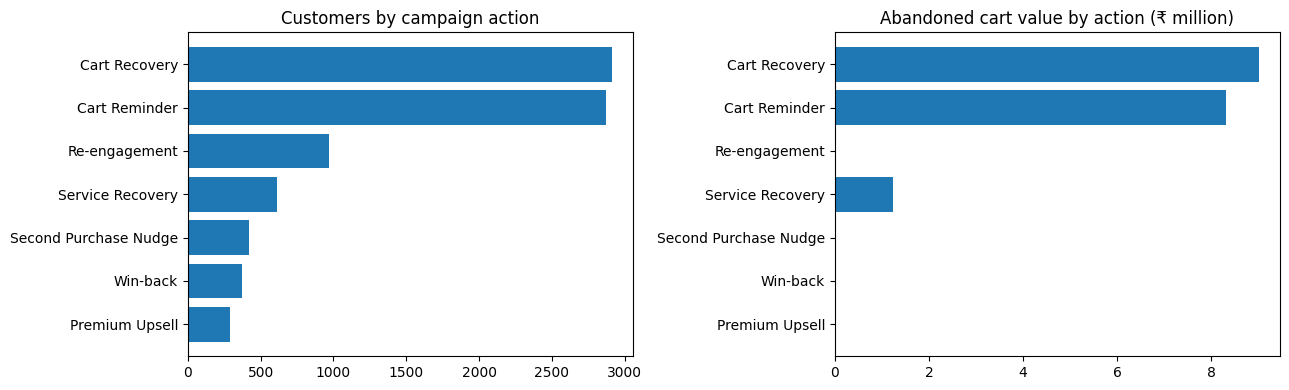

Cart Recovery customers: 2,911 | their abandoned value after discount: ₹8,342,984


,assumed_recovery_rate,extra_revenue_₹
0,5%,417149
1,10%,834298
2,15%,1251448


In [87]:
# ============================================================
# 9.5  CAMPAIGN SUMMARY
# ============================================================
summary = (marketing_actions.groupby("action")
           .agg(customers=("customer_id", "count"),
                avg_recovery_score=("recovery_score", lambda s: s[s > 0].mean()),
                total_abandoned_cart_value=("abandoned_cart_value", "sum"),
                avg_discount_pct=("discount_pct", "mean"))
           .round(2).sort_values("customers", ascending=False).reset_index())
display(summary)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].barh(summary["action"], summary["customers"]); ax[0].set_title("Customers by campaign action"); ax[0].invert_yaxis()
ax[1].barh(summary["action"], summary["total_abandoned_cart_value"] / 1e6); ax[1].set_title("Abandoned cart value by action (₹ million)"); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

# Scenario (ASSUMPTION, not a prediction): extra revenue if x% of Cart Recovery customers complete their purchase
cr = marketing_actions[marketing_actions["action"] == "Cart Recovery"]
net_after_discount = (cr["abandoned_cart_value"] * (1 - cr["discount_pct"] / 100)).sum()
scenario = pd.DataFrame({"assumed_recovery_rate": ["5%", "10%", "15%"],
                         "extra_revenue_₹": [round(net_after_discount * r) for r in (0.05, 0.10, 0.15)]})
print(f"Cart Recovery customers: {len(cr):,} | their abandoned value after discount: ₹{net_after_discount:,.0f}")
display(scenario)

In [88]:
# Top 20 customers to contact first (Cart Recovery, ranked by expected recovery value)
top20 = (marketing_actions[marketing_actions["action"] == "Cart Recovery"]
         .sort_values("expected_recovery_value", ascending=False).head(20))
display(top20[["customer_id", "rfm_segment", "recovery_score", "abandoned_cart_value",
               "expected_recovery_value", "discount_pct", "category_label", "message"]])

# One-customer demo (use this in an interview)
def show_customer(customer_id):
    r = marketing_actions[marketing_actions["customer_id"] == customer_id].iloc[0]
    print("=" * 62); print(f"CUSTOMER {customer_id}"); print("=" * 62)
    print(f"Segment         : {r.rfm_segment}")
    print(f"Sentiment       : {r.sentiment}")
    print(f"Abandoned cart  : ₹{r.abandoned_cart_value:,.2f}  (recovery score {r.recovery_score}/100)")
    print(f"Category        : {r.category_label}   | popular items: {r.top_products}")
    print(f"\nDECISION        : {r.action}  |  discount {r.discount_pct}%")
    print(f"Why             : {r.policy_reason}")
    print(f"Writer          : {r.writer}")
    print(f"\nMESSAGE:\n{r.message}")
    print(f"Guardrails OK   : {r.guardrails_ok}")

show_customer(int(top20.iloc[0]["customer_id"]))

,customer_id,rfm_segment,recovery_score,abandoned_cart_value,expected_recovery_value,discount_pct,category_label,message
4165,5419,Lapsed Buyers (At Risk),84,16232.79,6580.19,5,Category 6,You left something in your Category 6 cart. Ta...
5528,6874,Cart Abandoner (No Purchase),60,16497.64,5926.76,10,Category 0,You left something in your Category 0 cart. Ta...
6432,7838,Cart Abandoner (No Purchase),65,15570.75,5750.20,10,Category 4,You left something in your Category 4 cart. Ta...
6338,7738,Cart Abandoner (No Purchase),77,14726.84,5737.42,5,Category 3,You left something in your Category 3 cart. Ta...
7905,9423,Cart Abandoner (No Purchase),81,14173.90,5641.55,5,Category 6,You left something in your Category 6 cart. Ta...
1807,2917,Cart Abandoner (No Purchase),82,13590.53,5433.87,5,Category 6,You left something in your Category 6 cart. Ta...
8307,9854,Cart Abandoner (No Purchase),72,14052.76,5371.82,10,Category 3,You left something in your Category 3 cart. Ta...
2119,3249,Cart Abandoner (No Purchase),78,13596.89,5327.25,5,Category 6,You left something in your Category 6 cart. Ta...
2780,3946,Cart Abandoner (No Purchase),60,14373.17,5181.25,10,Category 3,You left something in your Category 3 cart. Ta...
2329,3471,Cart Abandoner (No Purchase),63,13913.34,5090.93,10,Category 5,You left something in your Category 5 cart. Ta...


CUSTOMER 5419
Segment         : Lapsed Buyers (At Risk)
Sentiment       : Positive
Abandoned cart  : ₹16,232.79  (recovery score 84/100)
Category        : Category 6   | popular items: #64, #94, #113

DECISION        : Cart Recovery  |  discount 5%
Why             : abandoned cart, recovery_score 84 >= 50
Writer          : template

MESSAGE:
You left something in your Category 6 cart. Take another look whenever it suits you. Approved offer: 5% off. You can unsubscribe from marketing messages anytime.
Guardrails OK   : True


In [89]:
# ============================================================
# 9.6  OPTIONAL: run with a REAL LLM (needs ANTHROPIC_API_KEY or OPENAI_API_KEY in the environment)
# ============================================================
USE_REAL_LLM = bool(os.environ.get("ANTHROPIC_API_KEY") or os.environ.get("OPENAI_API_KEY"))
print("Real LLM key found:", USE_REAL_LLM)
if USE_REAL_LLM:
    sample = customer_master[customer_master["has_abandoned_cart"]].head(5)
    for _, r in sample.iterrows():
        out = run_agents(r, use_llm=True)
        print(out["customer_id"], out["writer"], "->", out["message"], "\n")
else:
    print("No key -> template mode. In Colab: from google.colab import userdata; os.environ['ANTHROPIC_API_KEY'] = userdata.get('ANTHROPIC_API_KEY')")

Real LLM key found: False
No key -> template mode. In Colab: from google.colab import userdata; os.environ['ANTHROPIC_API_KEY'] = userdata.get('ANTHROPIC_API_KEY')


### 🎤 INTERVIEW CARD — Phase 9 (Campaign decision engine + LLM writer)

| | |
|---|---|
| **Kyun** | Insights ko action mein badalna: kis customer ko kya message, kitna discount. |
| **Kya** | Har customer → segment, cart-recovery score, sentiment, category → **action + discount + message**. |
| **Kaise** | **Policy agent (Python rules)** action aur discount tay karta hai. **LLM Writer** sirf shabd likhta hai. **Guardrails** (Python) discount cap, banned words, numbers, opt-out line check karte hain; LLM fail ho to safe template. |
| **Result** | 7 actions, 8,442 customers; sab tests pass (dead-branch detector, discount cap, guardrail, no raw category codes). |
| **Limit** | Policy thresholds (50/75 score, 5/10% discount) **business assumptions** hain — data se seekhe nahi gaye; A/B test se validate karna hoga. LLM path kisi real API key ke bina tested nahi (fake LLM se guardrail logic test hua). |

**Interviewer poochhe to:**
- *Ye "agent" hai ya sirf rules?* → Honest: deterministic policy + LLM writer + validator — "agentic workflow". Autonomous planning nahi hai; business ke liye wahi safe hai.
- *LLM ko discount kyun nahi dete?* → Hallucination ka risk; paise wala decision Python ka.
- *Guardrails kya check karte hain?* → Discount ≤ 15%, banned phrases, LLM ne koi number/percentage nahi likha, opt-out line.
- *Pehle kya bug tha?* → Policy mein segment ke naam galat the (`'Champions'` vs `'Champions (High Value)'`), do actions kabhi fire nahi hote the. Ab test (`dead-branch detector`) har action ki reachability check karta hai.

# PHASE 10 — STREAMLIT DASHBOARD + FLASK API

* `app.py` (Streamlit) reads `data/customer_marketing_actions.csv`. **It does not need the notebook to be running.**
* `api.py` (Flask) exposes the same table as JSON (`/health`, `/customer/<id>`, `/campaign/summary`).

The cell below saves the data files + `app.py` + `requirements.txt`. The *Cloudflare* cell afterwards is only a **temporary Colab demo link** (dies when the Colab session ends) — real deployment is explained in Phase 12.

In [90]:
# ============================================================
# 10.1  SAVE DATA FILES FOR THE APP
# ============================================================
from pathlib import Path
Path("data").mkdir(exist_ok=True)
Path("bi_exports").mkdir(exist_ok=True)

marketing_actions.to_csv("data/customer_marketing_actions.csv", index=False)
customer_master.to_csv("data/customer_master.csv", index=False)
summary.to_csv("data/campaign_summary.csv", index=False)
print("saved:", [p.name for p in Path("data").glob("*.csv")])

saved: ['customer_marketing_actions.csv', 'campaign_summary.csv', 'customer_master.csv']


In [91]:
# ============================================================
# 10.2  WRITE app.py, api.py, requirements.txt  (download them from the Colab file panel)
# ============================================================
APP_CODE = r'''"""E-Commerce Customer Intelligence - Streamlit dashboard.

Run:  streamlit run app.py
Data: data/customer_marketing_actions.csv (created by the notebook, Phase 10)
"""
from pathlib import Path

import pandas as pd
import streamlit as st

st.set_page_config(page_title="E-Commerce Customer Intelligence", page_icon="🛍️", layout="wide")

HERE = Path(__file__).resolve().parent


def find_file(name):
    for base in (HERE / "data", HERE, Path("data"), Path(".")):
        p = base / name
        if p.exists():
            return p
    st.error(f"`{name}` not found. Run the notebook (Phase 10) first so it creates data/{name}.")
    st.stop()


@st.cache_data
def load():
    return pd.read_csv(find_file("customer_marketing_actions.csv"))


df = load()

st.sidebar.title("🛍️ Customer Intelligence")
page = st.sidebar.radio("Go to", ["Overview", "Customer lookup", "Campaign list", "About & limits"])

# ------------------------------------------------------------------ Overview
if page == "Overview":
    st.title("Overview")
    cr = df[df["action"] == "Cart Recovery"]
    c = st.columns(4)
    c[0].metric("Customers", f"{len(df):,}")
    c[1].metric("Abandoned cart value", f"₹{df['abandoned_cart_value'].sum() / 1e6:.1f}M")
    c[2].metric("Cart Recovery targets", f"{len(cr):,}")
    c[3].metric("Average discount offered", f"{df['discount_pct'].mean():.1f}%")

    left, right = st.columns(2)
    with left:
        st.subheader("Customers by campaign action")
        st.bar_chart(df["action"].value_counts())
    with right:
        st.subheader("Customers by segment")
        st.bar_chart(df["rfm_segment"].value_counts())

    st.subheader("Review sentiment (latest genuine review)")
    st.bar_chart(df["sentiment"].value_counts())
    st.caption("`No review` = customer never bought or never rated. They are not counted as Neutral.")

# ------------------------------------------------------------------ Customer lookup
elif page == "Customer lookup":
    st.title("Customer lookup")
    lo, hi = int(df["customer_id"].min()), int(df["customer_id"].max())
    cid = st.number_input(f"Customer ID ({lo} - {hi})", min_value=lo, max_value=hi, value=lo, step=1)
    row = df[df["customer_id"] == cid]
    if row.empty:
        st.warning("No customer with this ID.")
    else:
        r = row.iloc[0]
        c = st.columns(4)
        c[0].metric("Segment", r["rfm_segment"])
        c[1].metric("Sentiment", r["sentiment"])
        c[2].metric("Abandoned cart", f"₹{r['abandoned_cart_value']:,.0f}")
        c[3].metric("Recovery score (0-100)", int(r["recovery_score"]) if r["abandoned_cart_value"] > 0 else "n/a")

        st.subheader("Decision")
        d = st.columns(3)
        d[0].success(f"**Action:** {r['action']}")
        d[1].success(f"**Discount:** {int(r['discount_pct'])}%")
        d[2].info(f"**Category:** {r['category_label']}")
        st.caption(f"Why: {r['policy_reason']}")
        if isinstance(r["top_products"], str) and r["top_products"]:
            st.caption(f"Popular items in this category: {r['top_products']}")

        st.subheader("Message")
        st.write(r["message"])
        st.caption(f"Written by: {r['writer']}  |  Guardrails passed: {bool(r['guardrails_ok'])}")

# ------------------------------------------------------------------ Campaign list
elif page == "Campaign list":
    st.title("Campaign list")
    actions = sorted(df["action"].unique())
    chosen = st.multiselect("Action", actions, default=["Cart Recovery"])
    view = df[df["action"].isin(chosen)] if chosen else df
    view = view.sort_values("expected_recovery_value", ascending=False)
    st.write(f"{len(view):,} customers")
    cols = ["customer_id", "rfm_segment", "action", "discount_pct", "recovery_score",
            "abandoned_cart_value", "expected_recovery_value", "category_label", "message"]
    st.dataframe(view[cols].head(500))
    st.download_button("Download this list (CSV)", view[cols].to_csv(index=False).encode("utf-8"),
                       file_name="campaign_list.csv", mime="text/csv")

# ------------------------------------------------------------------ About
else:
    st.title("About & limits")
    st.markdown(
        """
**What this is:** a campaign decision engine built on a 25,000-session customer dataset (8,442 customers).
Segments come from purchase-based RFM + K-Means. A rule-based *policy* picks the action and discount;
an LLM (or a safe template) only writes the wording; Python guardrails check every message.

**Honest limits**
- Predicting *who will buy* is weak on this data (cross-validated AUC about 0.57, vs 0.50 for random labels).
  The **recovery score is a ranking** used to prioritise carts, not a probability or a promise.
- Discount sizes and score thresholds are **business assumptions** that should be validated with an A/B test.
- Review text in the source file is encoded, so sentiment is derived from star ratings.
- The recommender performs at random-chance level on this dataset (no co-purchase signal).
        """
    )
'''

API_CODE = r'''"""Flask JSON API over the campaign table.

Run:  python api.py          (http://localhost:5000)
"""
import json
from pathlib import Path

import pandas as pd
from flask import Flask, jsonify

HERE = Path(__file__).resolve().parent
CSV = next((p for p in (HERE / "data" / "customer_marketing_actions.csv", HERE / "customer_marketing_actions.csv") if p.exists()), None)
if CSV is None:
    raise FileNotFoundError("customer_marketing_actions.csv not found - run the notebook (Phase 10) first")

app = Flask(__name__)
df = pd.read_csv(CSV)


def records(frame):
    # to_json turns NaN into null, so the response is always valid JSON
    return json.loads(frame.to_json(orient="records"))


@app.get("/health")
def health():
    return {"status": "ok", "customers": int(len(df))}


@app.get("/campaign/summary")
def campaign_summary():
    s = (df.groupby("action")
           .agg(customers=("customer_id", "count"),
                abandoned_cart_value=("abandoned_cart_value", "sum"),
                avg_discount_pct=("discount_pct", "mean"))
           .round(2).reset_index())
    return jsonify(records(s))


@app.get("/customer/<int:customer_id>")
def customer(customer_id):
    row = df[df["customer_id"] == customer_id]
    if row.empty:
        return jsonify(error="customer not found"), 404
    return jsonify(records(row)[0])


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)
'''

Path("app.py").write_text(APP_CODE, encoding="utf-8")
Path("api.py").write_text(API_CODE, encoding="utf-8")
Path("requirements.txt").write_text("""# Deploy / run the app + API
streamlit>=1.40
pandas>=2.0
flask>=3.0
""", encoding="utf-8")
print("written: app.py, api.py, requirements.txt")

written: app.py, api.py, requirements.txt


In [ ]:
# ============================================================
# 10.3  (COLAB ONLY) temporary public link for a demo — dies when the Colab session ends
# ============================================================
import os, re, time
from pathlib import Path

os.system("pip -q install streamlit")
os.system("pkill -f 'streamlit run' 2>/dev/null || true")
os.system("pkill -f cloudflared 2>/dev/null || true")
time.sleep(2)
os.system("nohup streamlit run app.py --server.port 8501 --server.address 0.0.0.0 --server.headless true > /tmp/streamlit.log 2>&1 &")
time.sleep(6)

if not Path("/content/cloudflared").exists():
    os.system("wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared && chmod +x /content/cloudflared")
os.system("nohup /content/cloudflared tunnel --url http://127.0.0.1:8501 > /tmp/cloudflared.log 2>&1 &")
time.sleep(8)

urls = re.findall(r"https://[a-zA-Z0-9-]+\.trycloudflare\.com", Path("/tmp/cloudflared.log").read_text(errors="ignore"))
print("TEMPORARY LINK:", urls[-1] if urls else "not ready yet - run this cell again in 10 seconds")

# PHASE 11 — BI EXPORTS (Power BI / Tableau)

The cell below writes clean, analysis-ready CSVs into `bi_exports/`. **Dashboards themselves you build in Power BI Desktop / Tableau Public** — a screenshot of your own dashboard is what goes into the README.

**Suggested Power BI pages (one question per page)**
1. **Sales health** — cards: Gross, **Net**, Cancel rate; line: daily net revenue; bar: category; map/bar: state. Source: `sales_*.csv`
2. **Customer segments** — donut customers by `rfm_segment`; bar revenue by segment. Source: `customer_master.csv`
3. **Cart recovery** — card: abandoned value; table: top customers by `expected_recovery_value`; slicer: `action`. Source: `marketing_actions.csv`

**Starter DAX measures**
```DAX
Net Revenue   = CALCULATE ( SUM ( sales_status[amount] ), sales_status[status_group] = "Completed" )
Gross Revenue = SUM ( sales_status[amount] )
Cancel Rate   = DIVIDE ( CALCULATE ( SUM ( sales_status[order_lines] ), sales_status[status_group] = "Cancelled" ), SUM ( sales_status[order_lines] ) )
Abandoned Value = SUM ( marketing_actions[abandoned_cart_value] )
```

In [93]:
# ============================================================
# 11.1  BI EXPORTS
# ============================================================
sales = df.copy()                                   # cleaned sales data (Phase 1) incl. status_group
sales["net_amount"] = sales["Amount"].where(sales["status_group"] == "Completed", 0).fillna(0)
sales["gross_amount"] = sales["Amount"].fillna(0)

sales_status = (sales.groupby(["status_group", "Status"]).agg(order_lines=("Order ID", "size"), amount=("gross_amount", "sum")).reset_index())
sales_daily = (sales.groupby(sales["Date"].dt.date).agg(orders=("Order ID", "nunique"), gross=("gross_amount", "sum"), net=("net_amount", "sum")).reset_index().rename(columns={"Date": "date"}))
sales_category = (sales.groupby("Category").agg(gross=("gross_amount", "sum"), net=("net_amount", "sum"), order_lines=("Order ID", "size")).reset_index())
sales_state = (sales.groupby("ship-state").agg(gross=("gross_amount", "sum"), net=("net_amount", "sum"), order_lines=("Order ID", "size")).reset_index().rename(columns={"ship-state": "state"}))
sales_fulfilment = (sales.groupby("Fulfilment").agg(order_lines=("Order ID", "size"), cancel_rate=("status_group", lambda s: (s == "Cancelled").mean()), net=("net_amount", "sum")).reset_index())

exports = {"sales_status": sales_status, "sales_daily": sales_daily, "sales_category": sales_category,
           "sales_state": sales_state, "sales_fulfilment": sales_fulfilment,
           "customer_master": customer_master, "marketing_actions": marketing_actions, "campaign_summary": summary,
           "rfm_segments": rfm_corrected[["customer_id", "recency", "frequency", "monetary", "segment"]],
           "cart_sessions_scored": cart_scored[["customer_id", "session_id", "visit_date", "product_id", "product_category",
                                                "cart_value", "marketing_channel", "device_type", "purchased", "cart_purchase_prob"]]}
for name, frame in exports.items():
    frame.to_csv(f"bi_exports/{name}.csv", index=False)
print("bi_exports/:", sorted(p.name for p in Path("bi_exports").glob("*.csv")))

bi_exports/: ['campaign_summary.csv', 'cart_sessions_scored.csv', 'customer_master.csv', 'marketing_actions.csv', 'rfm_segments.csv', 'sales_category.csv', 'sales_daily.csv', 'sales_fulfilment.csv', 'sales_state.csv', 'sales_status.csv']
